## Import thư viện

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import StandardScaler
from prophet import Prophet
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px

## Đọc dữ liệu

In [105]:
df = pd.read_csv("../data/new_retail_data.csv")
pd.set_option('display.max_columns', None)
df.head(5)

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,21.0,Male,Low,Regular,9/18/2023,2023.0,September,22:03:55,3.0,108.028757,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,19.0,Female,Low,Premium,12/31/2023,2023.0,December,8:42:04,2.0,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,48.0,Male,Low,Regular,4/26/2023,2023.0,April,4:06:29,3.0,354.477600,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,56.0,Male,High,Premium,5/8/2023,2023.0,May,14:55:17,7.0,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,22.0,Male,Low,Premium,1/10/2024,2024.0,January,16:54:07,2.0,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


- Như chúng ta thấy dữ liệu đầu vào có rất nhiều lỗi khi số điện thoại và các ID và năm chưa được chuẩn hóa 

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    301677 non-null  float64
 1   Customer_ID       301702 non-null  float64
 2   Name              301628 non-null  object 
 3   Email             301663 non-null  object 
 4   Phone             301648 non-null  float64
 5   Address           301695 non-null  object 
 6   City              301762 non-null  object 
 7   State             301729 non-null  object 
 8   Zipcode           301670 non-null  float64
 9   Country           301739 non-null  object 
 10  Age               301837 non-null  float64
 11  Gender            301693 non-null  object 
 12  Income            301720 non-null  object 
 13  Customer_Segment  301795 non-null  object 
 14  Date              301651 non-null  object 
 15  Year              301660 non-null  float64
 16  Month             30

- Có rất nhiều dữ liệu NULL

## **Tiền xử lý dữ liệu**

### Chuẩn hóa kiểu dữ liệu

In [107]:
# Chuyển các cột số liệu sang kiểu int64 hoặc float64, bỏ qua NaN
df['Transaction_ID'] = pd.to_numeric(df['Transaction_ID'], errors='coerce').astype('Int64')  # Dùng 'Int64' để giữ NaN
df['Customer_ID'] = pd.to_numeric(df['Customer_ID'], errors='coerce').astype('Int64')  # Dùng 'Int64' để giữ NaN
df['Ratings'] = pd.to_numeric(df['Ratings'], errors='coerce').astype('Int64')  # Dùng 'Int64' để giữ NaN
df['Age'] = pd.to_numeric(df['Age'], errors='coerce').astype('Int64')  # Dùng 'Int64' để giữ NaN
df['Zipcode'] = pd.to_numeric(df['Zipcode'], errors='coerce').astype('Int64')
df['Phone'] = pd.to_numeric(df['Phone'], errors='coerce').astype('Int64')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

# Chuyển các cột số thực sang kiểu float64
df['Total_Purchases'] = pd.to_numeric(df['Total_Purchases'], errors='coerce').astype('float64')
df['Total_Amount'] = pd.to_numeric(df['Total_Amount'], errors='coerce').astype('float64')

# Chuyển các cột còn lại sang kiểu object (cho các cột văn bản và phân loại)
df['Name'] = df['Name'].astype('object')
df['Email'] = df['Email'].astype('object')
df['Phone'] = df['Phone'].astype('string')  # Phone có thể là số nhưng dạng chuỗi nếu có dấu phân cách
df['Address'] = df['Address'].astype('object')
df['City'] = df['City'].astype('object')
df['State'] = df['State'].astype('object')
df['Zipcode'] = df['Zipcode'].astype('string')  # Zipcode có thể chứa ký tự
df['Country'] = df['Country'].astype('object')
df['Gender'] = df['Gender'].astype('object')
df['Income'] = df['Income'].astype('object')
df['Year'] = df['Year'].astype('object')
df['Customer_Segment'] = df['Customer_Segment'].astype('object')

# Chuyển cột 'Date' thành datetime, bỏ qua lỗi nếu có NaT
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # Chuyển 'Date' thành datetime, sẽ trở thành NaT nếu lỗi

# Còn lại các cột kiểu object
df['Month'] = df['Month'].astype('object')
df['Time'] = df['Time'].astype('object')
df['Product_Category'] = df['Product_Category'].astype('object')
df['Product_Brand'] = df['Product_Brand'].astype('object')
df['Product_Type'] = df['Product_Type'].astype('object')
df['Feedback'] = df['Feedback'].astype('object')
df['Shipping_Method'] = df['Shipping_Method'].astype('object')
df['Payment_Method'] = df['Payment_Method'].astype('object')
df['Order_Status'] = df['Order_Status'].astype('object')
df['products'] = df['products'].astype('object')

- Đầu tiên ta sẽ chuẩn hóa các kiểu dữ liệu về dạng đúng để có thể xử lí dễ dàng hơn

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Transaction_ID    301677 non-null  Int64         
 1   Customer_ID       301702 non-null  Int64         
 2   Name              301628 non-null  object        
 3   Email             301663 non-null  object        
 4   Phone             301648 non-null  string        
 5   Address           301695 non-null  object        
 6   City              301762 non-null  object        
 7   State             301729 non-null  object        
 8   Zipcode           301670 non-null  string        
 9   Country           301739 non-null  object        
 10  Age               301837 non-null  Int64         
 11  Gender            301693 non-null  object        
 12  Income            301720 non-null  object        
 13  Customer_Segment  301795 non-null  object        
 14  Date

### Xem dữ liệu bị thiếu

In [109]:
df.isna().sum()

Transaction_ID      333
Customer_ID         308
Name                382
Email               347
Phone               362
Address             315
City                248
State               281
Zipcode             340
Country             271
Age                 173
Gender              317
Income              290
Customer_Segment    215
Date                359
Year                350
Month               273
Time                350
Total_Purchases     361
Amount              357
Total_Amount        350
Product_Category    283
Product_Brand       281
Product_Type          0
Feedback            184
Shipping_Method     337
Payment_Method      297
Order_Status        235
Ratings             184
products              0
dtype: int64

### Chuẩn hóa cột State

In [110]:
usa_cities_states = pd.read_csv("../data/usa_cities_states.csv")
australia_cities_states = pd.read_csv("../data/australia_cities_states.csv")
germany_cities_states = pd.read_csv("../data/stateandcityofgermany.csv")
uk_cities_states = pd.read_csv("../data/uk_cities_states.csv")
canada_cities_states = pd.read_csv("../data/Cities_and_Their_States_in_Canada.csv")

- Vì dữ liệu state ban đầu đưa vào chỉ đúng state với USA, còn với các nước còn lại đều gán cho 1 state cố định nên ta sẽ xử dụng dữ liệu các state của các nước trên thực tế để sửa lại

In [111]:
# Thêm cột 'Country' vào các DataFrame về states
usa_cities_states['Country'] = 'USA'
australia_cities_states['Country'] = 'Australia'
germany_cities_states['Country'] = 'Germany'
uk_cities_states['Country'] = 'UK'
canada_cities_states['Country'] = 'Canada'

# Merge các DataFrame đã có cột 'Country' vào df
df_merged = pd.merge(df, usa_cities_states[['City', 'State', 'Country']], left_on=['City', 'Country'], right_on=['City', 'Country'], how='left', suffixes=('', '_usa'))
df_merged = pd.merge(df_merged, australia_cities_states[['City', 'State', 'Country']], left_on=['City', 'Country'], right_on=['City', 'Country'], how='left', suffixes=('', '_aus'))
df_merged = pd.merge(df_merged, germany_cities_states[['City', 'State', 'Country']], left_on=['City', 'Country'], right_on=['City', 'Country'], how='left', suffixes=('', '_ger'))
df_merged = pd.merge(df_merged, uk_cities_states[['City', 'State', 'Country']], left_on=['City', 'Country'], right_on=['City', 'Country'], how='left', suffixes=('', '_uk'))
df_merged = pd.merge(df_merged, canada_cities_states[['City', 'State', 'Country']], left_on=['City', 'Country'], right_on=['City', 'Country'], how='left', suffixes=('', '_can'))

# Cập nhật cột 'State' của df với giá trị từ các cột 'State' đã merge
df_merged['State'] = df_merged['State_usa'].fillna(df_merged['State_aus']).fillna(df_merged['State_ger']).fillna(df_merged['State_uk']).fillna(df_merged['State_can'])

# Xóa các cột 'State' với các suffixes
df_merged = df_merged.drop(columns=['State_usa', 'State_aus', 'State_ger', 'State_uk', 'State_can'])

# Xem kết quả
df = df_merged


### Điền dữ liệu bị thiếu cho cột City dựa vào các cột Country, Zipcode

In [112]:
# Lọc các hàng có 'City' và 'State' là NaN, nhưng 'Zipcode' và 'Country' không phải là NaN
df_filtered = df[
    df['City'].isna() & 
    df['State'].isna() & 
    df['Zipcode'].notna() & 
    df['Country'].notna()
]

df_filtered

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,Age,Gender,Income,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
30903,5695172,65712,Nathan Gardner,Michelle80@gmail.com,5098276425,422 David Streets Suite 704,NaN,NaN,67730,UK,22,Male,High,Regular,2023-04-13,2023,April,20:56:39,6.0,28.185125,169.110749,Clothing,Adidas,Jacket,Average,Standard,PayPal,Delivered,2,Peacoat
34227,2344287,35757,Ashley Joseph,Abigail53@gmail.com,3066902193,653 Meyer Inlet Suite 154,NaN,NaN,27436,USA,22,Female,Low,Regular,2023-09-07,2023,September,6:16:25,4.0,167.815723,671.262893,Home Decor,Home Depot,Tools,Excellent,Same-Day,PayPal,Delivered,4,Utility knife
36340,6311279,69037,Roger Richards,Michelle13@gmail.com,7133232064,11837 Hunter Gateway Apt. 230,NaN,NaN,71902,USA,22,Male,High,Regular,2023-03-06,2023,March,3:25:55,8.0,259.063949,2072.511594,Grocery,Coca-Cola,Soft Drink,Average,Standard,PayPal,Delivered,2,Orange soda
36701,6364411,97562,Joel Anderson,Sheri70@gmail.com,5962095186,13506 Garrett Mews,NaN,NaN,85943,Australia,22,Female,Low,Regular,2024-01-29,2024,January,23:41:03,6.0,397.515059,2385.090356,Books,HarperCollins,Non-Fiction,Excellent,Same-Day,Debit Card,Delivered,4,Psychology
38608,2001432,48237,Derek Mack,Amber98@gmail.com,6827421445,2323 Holder Green Apt. 393,NaN,NaN,39923,UK,22,Male,High,Regular,2023-05-01,2023,May,3:28:14,1.0,81.243538,81.243538,Grocery,Coca-Cola,Soft Drink,Average,Standard,Debit Card,Delivered,2,Ginger ale
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297945,7336754,90817,Robert White,Jennifer21@gmail.com,9504090439,177 Wallace Place,NaN,NaN,48928,UK,38,Male,High,New,2023-12-02,2023,December,5:30:00,7.0,196.492606,1375.448244,Electronics,Apple,Laptop,Good,Express,Credit Card,Processing,3,Asus ZenBook
298458,5975233,24987,Carolyn Smith,Brian16@gmail.com,4212625031,376 Avila Trail Suite 117,NaN,NaN,77843,Canada,56,Male,Low,New,2024-01-12,2024,January,9:48:41,9.0,276.603453,2489.431078,Electronics,Sony,Smartphone,Excellent,Express,Credit Card,Delivered,4,OnePlus
300229,3610472,35925,Joshua Schneider,Karen31@gmail.com,6944239255,203 Hoover Heights Suite 625,NaN,NaN,67206,UK,29,Female,High,Premium,2023-12-28,2023,December,22:56:52,9.0,39.751663,357.764969,Grocery,Coca-Cola,Water,Bad,Express,Credit Card,Pending,1,Purified water
300385,8595304,68082,Caleb Payne,Catherine31@gmail.com,8790678721,5578 Krystal Spring Suite 986,NaN,NaN,92100,UK,21,Male,Medium,Regular,2023-06-30,2023,June,17:44:59,3.0,495.074101,1485.222304,Home Decor,IKEA,Decorations,Bad,Express,Credit Card,Delivered,1,Sculptures


- Chúng ta kiểm tra xem các City và State Null nhưng Country và Zipcode không NULL để tiến hành xử lí các hàng này trước 

In [113]:
city_mapping = df.dropna(subset=['City'])[['Zipcode', 'Country', 'City']].groupby(['Zipcode', 'Country'])['City'].first()

# Điền giá trị 'City' từ groupby
df['City'] = df.apply(
    lambda row: city_mapping.get((row['Zipcode'], row['Country']), row['City']) 
    if pd.isna(row['City']) and pd.notna(row['Zipcode']) and pd.notna(row['Country']) else row['City'],
    axis=1
)

- Chúng ta sẽ dùng Country và Zipcode để xem các hàng tương ứng và fill vào City các hàng còn trống

In [114]:
df['City'].isna().sum()

138

### Điền dữ liệu bị thiếu cho cột State

In [115]:
state_mapping = df.dropna(subset=['State'])[['Zipcode', 'Country', 'State']].groupby(['Zipcode', 'Country'])['State'].first()

# Điền giá trị 'State' từ groupby
df['State'] = df.apply(
    lambda row: state_mapping.get((row['Zipcode'], row['Country']), row['State']) 
    if pd.isna(row['State']) and pd.notna(row['Zipcode']) and pd.notna(row['Country']) else row['State'],
    axis=1
)

- State và City có liên quan khá mật thiết nên sau khi fill xong City ta sẽ đến với State

In [116]:
# Sử dụng groupby để tạo bảng tra cứu cho State từ City
state_mapping = df.dropna(subset=['State'])[['City', 'State']].groupby('City')['State'].first()

# Điền giá trị 'State' từ groupby
df['State'] = df.apply(
    lambda row: state_mapping.get(row['City'], row['State']) 
    if pd.isna(row['State']) and pd.notna(row['City']) else row['State'],
    axis=1
)

In [117]:
df['State'].isna().sum()

138

### Điền dữ liệu bị thiếu cho cột Country

In [118]:
#Xử lí country
country_mapping = df.dropna(subset=['Country'])[['City', 'State', 'Country']].groupby(['City', 'State'])['Country'].first()

# Điền giá trị 'Country' từ groupby
df['Country'] = df.apply(
    lambda row: country_mapping.get((row['City'], row['State']), row['Country']) 
    if pd.isna(row['Country']) and pd.notna(row['City']) and pd.notna(row['State']) else row['Country'],
    axis=1
)

- Sau khi xử lí xong 2 cột State và City thì ta sẽ xử cột địa lí tiếp theo mà chúng ta sẽ sủ dụng trong việc phân tích  

In [119]:
df['Country'].isna().sum()

0

### Điền dữ liệu bị thiếu cho cột Transaction_ID

In [120]:
# Sử dụng groupby để tạo bảng tra cứu cho Transaction_ID từ Customer_ID và Date
transaction_mapping = df.dropna(subset=['Transaction_ID'])[['Customer_ID', 'Date', 'Transaction_ID']].groupby(['Customer_ID', 'Date'])['Transaction_ID'].first()

# Điền giá trị 'Transaction_ID' từ groupby
df['Transaction_ID'] = df.apply(
    lambda row: transaction_mapping.get((row['Customer_ID'], row['Date']), row['Transaction_ID']) 
    if pd.isna(row['Transaction_ID']) and pd.notna(row['Customer_ID']) and pd.notna(row['Date']) else row['Transaction_ID'],
    axis=1
)

- Dựa vào Customer_ID và ngày đặt hàng ta sẽ sử dụng để fill vào cột Transaction_ID còn thiếu 

In [121]:
max_transaction_id = df['Transaction_ID'].max()
# Điền các giá trị NaN trong Transaction_ID bằng giá trị lớn nhất hiện tại
df['Transaction_ID'] = df['Transaction_ID'].fillna(max_transaction_id)
# Tạo một chỉ số tăng dần cho các dòng NaN sau khi điền giá trị lớn nhất
df['Transaction_ID'] = df['Transaction_ID'] + df['Transaction_ID'].isna().cumsum()

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\2098715913.py:3: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



- Với những hàng còn lại là giá trị các Transaction độc nhất không có thông tin dựa vào để fill, ta sẽ tạo cho chúng ID mới dựa trên ID lớn nhất 

In [122]:
df['Transaction_ID'].isna().sum()

0

### Điền dữ liệu bị thiếu cho cột Name

In [123]:
df_name_map = df.dropna(subset=['Name'])[['Customer_ID', 'Transaction_ID', 'Name']].drop_duplicates()

# Điền giá trị 'Name' từ bảng tra cứu dựa trên 'Customer_ID' và 'Transaction_ID'
df['Name'] = df.apply(
    lambda row: df_name_map[(df_name_map['Customer_ID'] == row['Customer_ID']) & (df_name_map['Transaction_ID'] == row['Transaction_ID'])]['Name'].values[0]
    if pd.isnull(row['Name']) and not df_name_map[(df_name_map['Customer_ID'] == row['Customer_ID']) & (df_name_map['Transaction_ID'] == row['Transaction_ID'])].empty
    else row['Name'],
    axis=1
)

In [124]:
# Điền giá trị 'Unknown' cho các khách hàng bị thiếu 'Name'
df['Name'] = df['Name'].fillna('Unknown')

# Tạo một chỉ số tăng dần cho các khách hàng bị điền 'Unknown'
df['Name_Fill_Index'] = df.groupby('Name').cumcount() + 1

# Đảm bảo chỉ số tăng dần chỉ áp dụng cho khách hàng 'Unknown'
df.loc[df['Name'] == 'Unknown', 'Name'] = df.loc[df['Name'] == 'Unknown', 'Name_Fill_Index'].apply(lambda x: f'Unknown{x}')

# Bỏ chỉ số tăng dần trong cột Name_Fill_Index nếu không cần thiết nữa
df.drop('Name_Fill_Index', axis=1, inplace=True)



- Tương tự với Transaction_ID, Các hàng khách hàng này là độc nhất và ta không tìm được thông tin các hàng tương tự để fill vào nên ta sẽ tiến hành điền Unknown với thứ tự tăng dần cho các khách hàng này 

In [125]:
df['Name'].isna().sum()

0

### Điền dữ liệu bị thiếu cho các cột Age, Gender, Income và Customer_Segment

In [126]:
# Tạo bảng tra cứu cho cột 'Age' dựa trên cả 'Customer_ID' và 'Name'
df_age_map = df.dropna(subset=['Age'])[['Customer_ID', 'Name', 'Age']].drop_duplicates()
df['Age'] = df.apply(
    lambda row: df_age_map[(df_age_map['Customer_ID'] == row['Customer_ID']) & (df_age_map['Name'] == row['Name'])]['Age'].values[0]
    if pd.isnull(row['Age']) and not df_age_map[(df_age_map['Customer_ID'] == row['Customer_ID']) & (df_age_map['Name'] == row['Name'])].empty
    else row['Age'],
    axis=1
)

# Gender
df_gender_map = df.dropna(subset=['Gender'])[['Customer_ID', 'Name', 'Gender']].drop_duplicates()
df['Gender'] = df.apply(
    lambda row: df_gender_map[(df_gender_map['Customer_ID'] == row['Customer_ID']) & (df_gender_map['Name'] == row['Name'])]['Gender'].values[0] 
    if pd.isnull(row['Gender']) and not df_gender_map[(df_gender_map['Customer_ID'] == row['Customer_ID']) & (df_gender_map['Name'] == row['Name'])].empty
    else row['Gender'],
    axis=1
)

# Income
df_income_map = df.dropna(subset=['Income'])[['Customer_ID', 'Name', 'Income']].drop_duplicates()
df['Income'] = df.apply(
    lambda row: df_income_map[(df_income_map['Customer_ID'] == row['Customer_ID']) & (df_income_map['Name'] == row['Name'])]['Income'].values[0] 
    if pd.isnull(row['Income']) and not df_income_map[(df_income_map['Customer_ID'] == row['Customer_ID']) & (df_income_map['Name'] == row['Name'])].empty
    else row['Income'],
    axis=1
)

# Customer_Segment
df_customer_segment_map = df.dropna(subset=['Customer_Segment'])[['Customer_ID', 'Name', 'Customer_Segment']].drop_duplicates()
df['Customer_Segment'] = df.apply(
    lambda row: df_customer_segment_map[(df_customer_segment_map['Customer_ID'] == row['Customer_ID']) & (df_customer_segment_map['Name'] == row['Name'])]['Customer_Segment'].values[0] 
    if pd.isnull(row['Customer_Segment']) and not df_customer_segment_map[(df_customer_segment_map['Customer_ID'] == row['Customer_ID']) & (df_customer_segment_map['Name'] == row['Name'])].empty
    else row['Customer_Segment'],
    axis=1
)



In [127]:
df['Age'].isna().sum()

173

In [128]:
df['Income'].isna().sum()

289

In [129]:
df['Income'].unique()

array(['Low', 'High', 'Medium', nan], dtype=object)

In [130]:
df['Customer_Segment'].isna().sum()

214

In [131]:
df['Customer_Segment'].unique()

array(['Regular', 'Premium', 'New', nan], dtype=object)

### Điền dữ liệu bị thiếu cho các cột Feedback, Ratings, Shiping_Method_, Order_Status và Payment_Method 

In [132]:
# Feedback
df_feedback_map = df.dropna(subset=['Feedback'])[['Transaction_ID', 'Feedback']].drop_duplicates()
df['Feedback'] = df.apply(
    lambda row: df_feedback_map[df_feedback_map['Transaction_ID'] == row['Transaction_ID']]['Feedback'].values[0] 
    if pd.isnull(row['Feedback']) and row['Transaction_ID'] in df_feedback_map['Transaction_ID'].values else row['Feedback'],
    axis=1
)

# Shipping_Method
df_shipping_map = df.dropna(subset=['Shipping_Method'])[['Transaction_ID', 'Shipping_Method']].drop_duplicates()
df['Shipping_Method'] = df.apply(
    lambda row: df_shipping_map[df_shipping_map['Transaction_ID'] == row['Transaction_ID']]['Shipping_Method'].values[0] 
    if pd.isnull(row['Shipping_Method']) and row['Transaction_ID'] in df_shipping_map['Transaction_ID'].values else row['Shipping_Method'],
    axis=1
)

# Payment_Method
df_payment_map = df.dropna(subset=['Payment_Method'])[['Transaction_ID', 'Payment_Method']].drop_duplicates()
df['Payment_Method'] = df.apply(
    lambda row: df_payment_map[df_payment_map['Transaction_ID'] == row['Transaction_ID']]['Payment_Method'].values[0] 
    if pd.isnull(row['Payment_Method']) and row['Transaction_ID'] in df_payment_map['Transaction_ID'].values else row['Payment_Method'],
    axis=1
)

# Order_Status
df_order_status_map = df.dropna(subset=['Order_Status'])[['Transaction_ID', 'Order_Status']].drop_duplicates()
df['Order_Status'] = df.apply(
    lambda row: df_order_status_map[df_order_status_map['Transaction_ID'] == row['Transaction_ID']]['Order_Status'].values[0] 
    if pd.isnull(row['Order_Status']) and row['Transaction_ID'] in df_order_status_map['Transaction_ID'].values else row['Order_Status'],
    axis=1
)

# Ratings
df_ratings_map = df.dropna(subset=['Ratings'])[['Transaction_ID', 'Ratings']].drop_duplicates()
df['Ratings'] = df.apply(
    lambda row: df_ratings_map[df_ratings_map['Transaction_ID'] == row['Transaction_ID']]['Ratings'].values[0] 
    if pd.isnull(row['Ratings']) and row['Transaction_ID'] in df_ratings_map['Transaction_ID'].values else row['Ratings'],
    axis=1
)

In [133]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce').astype('Int64')

In [134]:
rate = df['Ratings'].unique()
print(rate)

[5 4 2 1 3 <NA>]


In [135]:
feedback = df['Feedback'].unique()
print(feedback)

['Excellent' 'Average' 'Bad' 'Good' nan]


In [136]:
df['Ratings'] = df['Ratings'].fillna(-1)

# Điền giá trị thiếu cho cột 'Feedback' bằng "No Feedback"
df['Feedback'] = df['Feedback'].fillna("No Feedback")


C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\2902559377.py:1: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



- Có thể đây là những đơn hàng mà khách không để lại đánh giá nên ta sẽ điền -1 và No feedback cho các giá trị còn thiếu 

### Điền dữ liệu bị thiếu cho cột Date

In [137]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.loc[df['Year'].isna(), 'Year'] = df.loc[df['Year'].isna(), 'Date'].dt.year
df.loc[df['Month'].isna(), 'Month'] = df.loc[df['Month'].isna(), 'Date'].dt.strftime('%B')

In [138]:
df_date_map = df.dropna(subset=['Date'])[['Transaction_ID', 'Date']].drop_duplicates()

# Điền giá trị 'Date' từ bảng tra cứu dựa trên 'Transaction_ID'
df['Date'] = df.apply(
    lambda row: df_date_map[df_date_map['Transaction_ID'] == row['Transaction_ID']]['Date'].values[0] 
    if pd.isnull(row['Date']) and row['Transaction_ID'] in df_date_map['Transaction_ID'].values else row['Date'],
    axis=1
)

### Điền dữ liệu bị thiếu cho cột Time

In [139]:
df_time_map = df.dropna(subset=['Time'])[['Transaction_ID', 'Time']].drop_duplicates()

# Điền giá trị 'Time' từ bảng tra cứu dựa trên 'Transaction_ID'
df['Time'] = df.apply(
    lambda row: df_time_map[df_time_map['Transaction_ID'] == row['Transaction_ID']]['Time'].values[0] 
    if pd.isnull(row['Time']) and row['Transaction_ID'] in df_time_map['Transaction_ID'].values else row['Time'],
    axis=1
)

### Điền dữ liệu bị thiếu cho cột Amount, Total_Amount, Total_Purchases

In [140]:
mask = (
    df["Total_Amount"].isnull() &
    df["Amount"].notnull() &
    df["Amount"].notnull()
    )

df.loc[mask, "Total_Amount"] = df.loc[mask, "Amount"] * df.loc[mask, "Total_Purchases"]

df = df[df["Total_Amount"].notnull()]

In [141]:
mask_purchases_null = df["Total_Purchases"].isnull() & df["Amount"].notnull()
df.loc[mask_purchases_null, "Total_Purchases"] = (
    df["Total_Amount"] / df["Amount"]
) 

mask_amount_null = df["Amount"].isnull() & df["Total_Purchases"].notnull()
df.loc[mask_amount_null, "Amount"] = (
    df["Total_Amount"] / df["Total_Purchases"]
)

In [142]:
df['Total_Amount'].isna().sum()

0

In [143]:
df['Amount'].isna().sum()

0

In [144]:
df['Total_Purchases'].isna().sum()

0

- Các cột Total_Amount, Amount, Total_Purchases có quan hệ mật thiết với nhau khi Total_Amount = Amount * Total_Purchases, ta sẽ dùng mối quan hệ này để điền thiếu cho các cột đó 

### Điền dữ liệu bị thiếu cho cột Product_Brand, Product_Category dựa vào cột Product

In [145]:
# Tạo bảng ánh xạ từ các dòng đã đầy đủ thông tin
mapping = df.dropna(subset=['Product_Brand', 'Product_Category']).drop_duplicates(subset=['products'])

# Tạo dict ánh xạ
brand_map = dict(zip(mapping['products'], mapping['Product_Brand']))
type_map = dict(zip(mapping['products'], mapping['Product_Category']))

In [146]:
df['Product_Brand'] = df['Product_Brand'].fillna(df['products'].map(brand_map))
df['Product_Category'] = df['Product_Category'].fillna(df['products'].map(type_map))

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\3737184599.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\3737184599.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [147]:
df['Product_Brand'].isna().sum()

0

In [148]:
df['Product_Category'].isna().sum()

0

### Loại bỏ các cột không sử dụng

In [149]:
cols_to_drop = [
    'Email', 'Phone', 'Address', 'Zipcode', 'Customer_ID', 'Year', 'Month'
]

df = df.drop(columns=cols_to_drop)


### Xóa giá trị thiếu

In [150]:
# df = df.dropna(subset=['City', 'Country', 'Gender', 'Date', 'Shipping_Method', 'Feedback', 'Payment_Method', 'Order_Status', 'Age', 'Income', 'Customer_Segment'])

df = df.dropna(subset=['Age', 'Date', 'Time', 'Order_Status', 'Payment_Method', 'Shipping_Method','Customer_Segment','State','Income','City','Gender'] )

- Đây là các giá trị mà không có thông tin liên quan để xử lí nên ta sẽ drop chúng đi 

Xử lí lại các Month và Year theo Date

In [151]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

df['Year'] = df['Date'].dt.year
df['Month_Num'] = df['Date'].dt.month
df['Month'] = df['Month_Num'].apply(lambda x: month_order[x-1])
df = df.drop(columns=['Month_Num'])

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299370 entries, 0 to 302009
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Transaction_ID    299370 non-null  int64         
 1   Name              299370 non-null  object        
 2   City              299370 non-null  object        
 3   State             299370 non-null  object        
 4   Country           299370 non-null  object        
 5   Age               299370 non-null  Int64         
 6   Gender            299370 non-null  object        
 7   Income            299370 non-null  object        
 8   Customer_Segment  299370 non-null  object        
 9   Date              299370 non-null  datetime64[ns]
 10  Time              299370 non-null  object        
 11  Total_Purchases   299370 non-null  float64       
 12  Amount            299370 non-null  float64       
 13  Total_Amount      299370 non-null  float64       
 14  Product_C

### Kiểm tra và xóa các dòng trùng lặp

In [153]:
df.duplicated().sum()

5

In [154]:
df.drop_duplicates(inplace=True)

### Kiểm tra dữ liệu sau khi đã tiền xử lý dữ liệu

In [155]:
df.isna().sum()

Transaction_ID      0
Name                0
City                0
State               0
Country             0
Age                 0
Gender              0
Income              0
Customer_Segment    0
Date                0
Time                0
Total_Purchases     0
Amount              0
Total_Amount        0
Product_Category    0
Product_Brand       0
Product_Type        0
Feedback            0
Shipping_Method     0
Payment_Method      0
Order_Status        0
Ratings             0
products            0
Year                0
Month               0
dtype: int64

In [156]:
df.duplicated().sum()

0

## Phân tích dữ liệu khám phá (EDA)

### 1. Tổng quan dữ liệu

#### Số lượng dòng và cột

In [157]:
df.shape

(299365, 25)

=> "Dữ liệu có tổng cộng 299,365 dòng (bản ghi) và 25 cột (thuộc tính)."

#### Kiểm tra kiểu dữ liệu

In [158]:
df.dtypes

Transaction_ID               int64
Name                        object
City                        object
State                       object
Country                     object
Age                          Int64
Gender                      object
Income                      object
Customer_Segment            object
Date                datetime64[ns]
Time                        object
Total_Purchases            float64
Amount                     float64
Total_Amount               float64
Product_Category            object
Product_Brand               object
Product_Type                object
Feedback                    object
Shipping_Method             object
Payment_Method              object
Order_Status                object
Ratings                      int64
products                    object
Year                         int32
Month                       object
dtype: object

=> "Dữ liệu có cả dạng số, dạng chuỗi và thời gian."

#### Số lượng giá trị duy nhất trong từng cột

In [159]:
df.nunique()

Transaction_ID      291871
Name                158816
City                   130
State                   74
Country                  5
Age                     53
Gender                   2
Income                   3
Customer_Segment         3
Date                   366
Time                 83602
Total_Purchases        214
Amount              297026
Total_Amount        297030
Product_Category         5
Product_Brand           18
Product_Type            33
Feedback                 5
Shipping_Method          3
Payment_Method           4
Order_Status             4
Ratings                  6
products               318
Year                     2
Month                   12
dtype: int64

=> "Tập dữ liệu có nhiều cột dạng phân loại với độ đa dạng cao – như 158 nghìn tên khách hàng, 33 loại sản phẩm, và 18 thương hiệu."

#### Thống kê mô tả cơ bản 

In [160]:
df.describe()

,Transaction_ID,Age,Date,Total_Purchases,Amount,Total_Amount,Ratings,Year
count,2.993650e+05,299365.0,299365,299365.000000,299365.000000,299365.000000,299365.000000,299365.000000
mean,5.500334e+06,35.473572,2023-08-30 16:44:49.083894272,5.359748,255.130577,1367.505973,3.159788,2023.165099
min,1.000007e+06,18.0,2023-03-01 00:00:00,1.000000,10.000219,10.003750,-1.000000,2023.000000
25%,3.249384e+06,22.0,2023-05-31 00:00:00,3.000000,132.861984,438.881833,2.000000,2023.000000
50%,5.503439e+06,32.0,2023-08-31 00:00:00,5.000000,255.448092,1040.979543,3.000000,2023.000000
75%,7.746784e+06,46.0,2023-11-30 00:00:00,8.000000,377.587125,2029.871536,4.000000,2023.000000
max,9.999995e+06,70.0,2024-02-29 00:00:00,10.000000,499.997911,4999.625796,5.000000,2024.000000
std,2.598731e+06,15.021909,NaN,2.868274,141.379159,1128.681173,1.324418,0.371271


=> "Tập dữ liệu gồm gần 300.000 giao dịch. Độ tuổi khách hàng dao động từ 18 đến 70, trung bình khoảng 35 tuổi. Mỗi giao dịch trung bình có khoảng 5 sản phẩm, với số tiền khoảng 255 đơn vị và tổng hóa đơn khoảng 1.368 đơn vị. Điểm đánh giá trung bình là 3.16 trên thang 5. Thời gian thu thập dữ liệu từ tháng 3/2023 đến hết tháng 2/2024."

#### Vẽ biểu đồ boxplot để kiểm tra giá trị outliner của các biến số

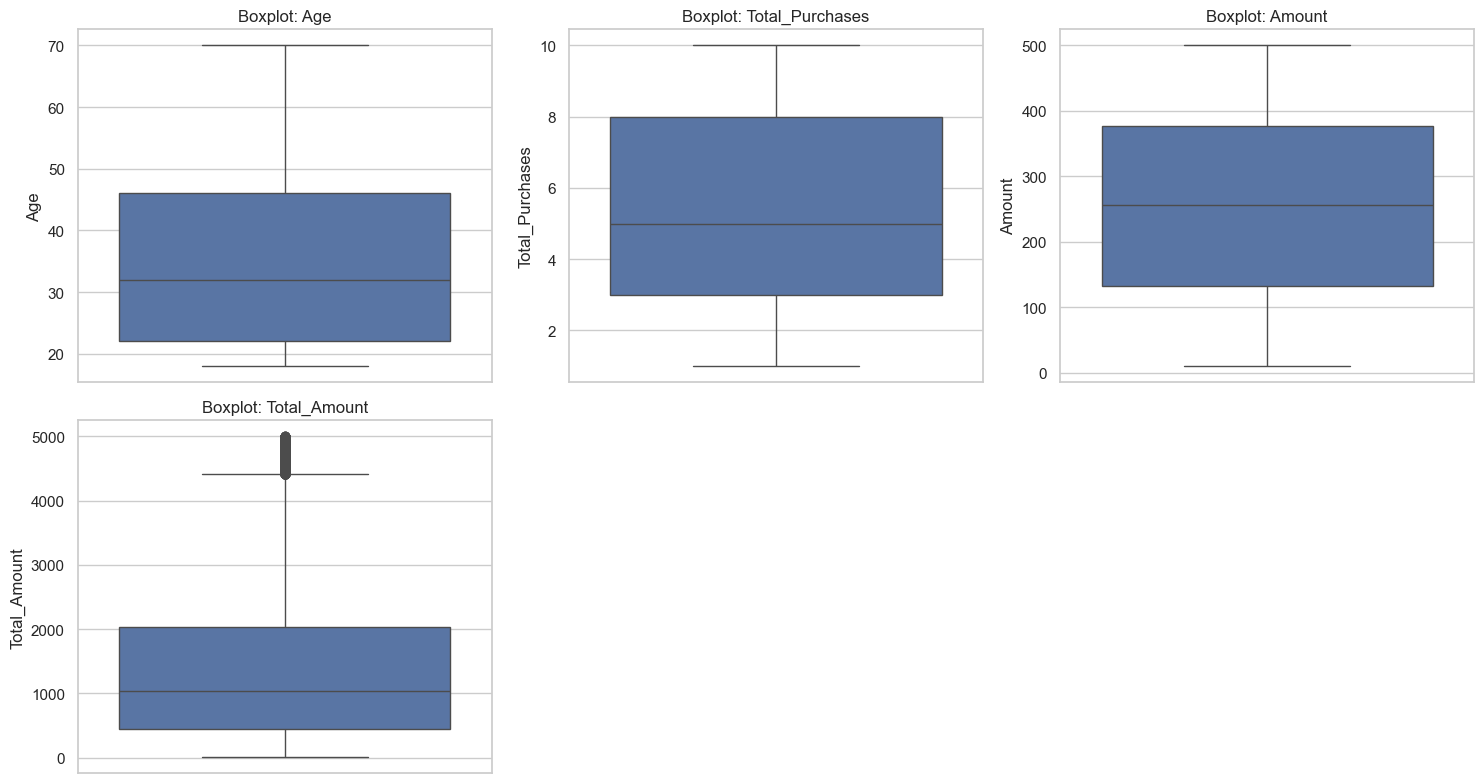

In [161]:
numeric_cols = ['Age', 'Total_Purchases', 'Amount', 'Total_Amount']

plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()

plt.show()

Tuổi (Age):
Khách hàng chủ yếu từ 20–50 tuổi, không có ngoại lai bất thường (18–70 tuổi).

Tổng lượt mua (Total_Purchases):
Trung bình ~5.36 lượt, đa số từ 3–8 lượt, không có ngoại lai lớn (tối đa 10 lượt).

Số tiền (Amount):
Trung bình ~255, phần lớn từ 130–380; một số ngoại lai cao (~500) nhưng hợp lý.

Tổng giá trị giao dịch (Total_Amount):
Trung bình ~1367, phổ biến từ 440–2000; một số cao đến gần 5000, có thể là giao dịch lớn.

### 2. Phân tích khách hàng

#### A. Nhân khẩu học

##### Phân bố độ tuổi khách hàng

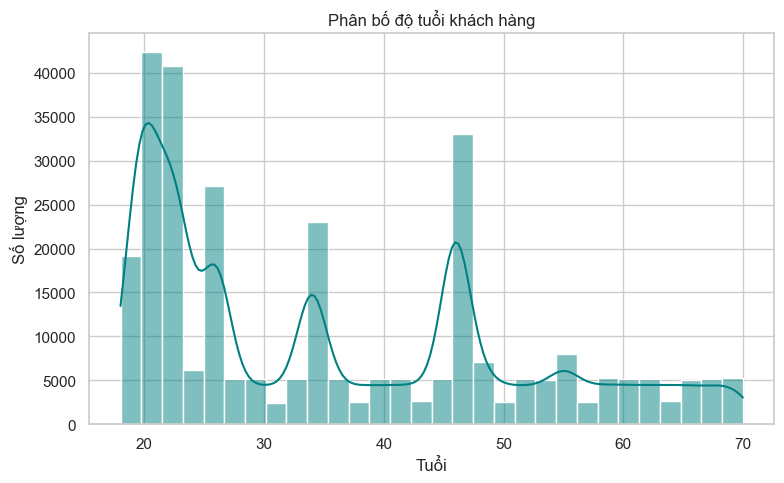

In [162]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='teal')
plt.title('Phân bố độ tuổi khách hàng')
plt.xlabel('Tuổi')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

- **Nhận xét:** Dữ liệu có sự phân bố khá đều về độ tuổi, nhưng phần lớn khách hàng thuộc nhóm độ tuổi từ 22 đến 46.

##### Tỷ lệ giới tính khách hàng

In [163]:
gender_counts = df['Gender'].value_counts()
gender_counts

Gender
Male      186150
Female    113215
Name: count, dtype: int64

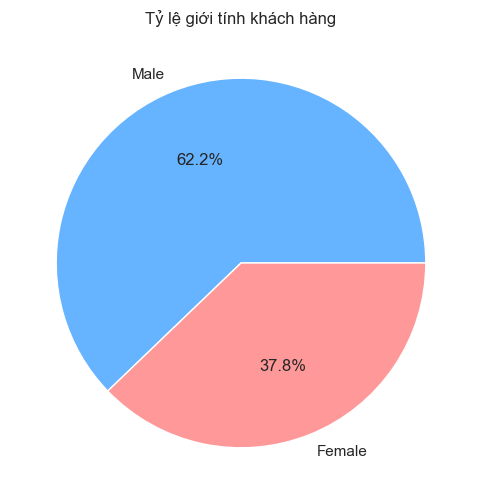

In [164]:
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
plt.title('Tỷ lệ giới tính khách hàng')
plt.show()


- **Nhận xét:** Tỷ lệ giới tính khá chênh lệch, với tỷ lệ nam chiếm đa số. Điều này có thể phản ánh sự ưu tiên của các sản phẩm dành cho đối tượng khách hàng nam hoặc chỉ ra xu hướng mua sắm của khách hàng theo giới tính.

##### Phân loại thu nhập của khách hàng

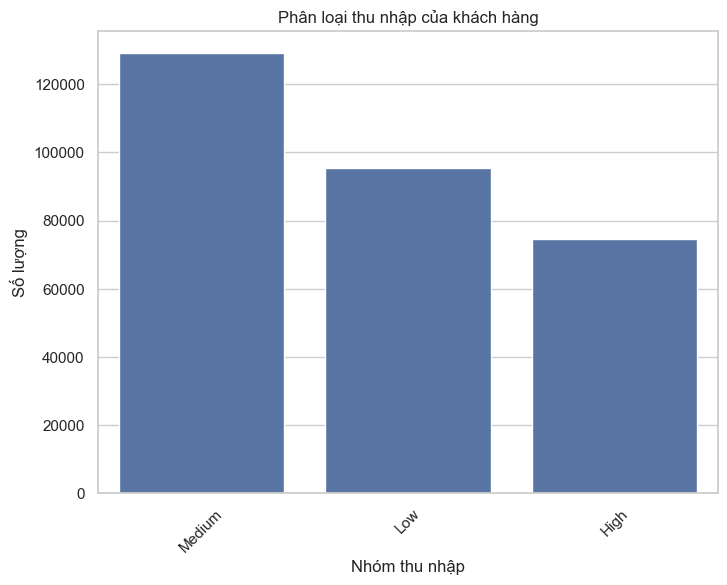

In [165]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Income', order=df['Income'].value_counts().index)
plt.title('Phân loại thu nhập của khách hàng')
plt.xlabel('Nhóm thu nhập')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
plt.show()


- **Nhận xét:** Phần lớn khách hàng thuộc nhóm thu nhập trung bình, tiếp theo là thu nhập thấp. Thu nhập cao chỉ chiếm một phần nhỏ, cho thấy sản phẩm hoặc dịch vụ có thể chủ yếu nhắm vào đối tượng khách hàng với thu nhập vừa phải.

##### Tổng lượt mua theo phân khúc khách hàng

In [166]:
segment_stats = df.groupby('Customer_Segment')['Total_Purchases'].sum().sort_values(ascending=False)
segment_stats

Customer_Segment
Regular    777116.0
New        486069.0
Premium    341336.0
Name: Total_Purchases, dtype: float64

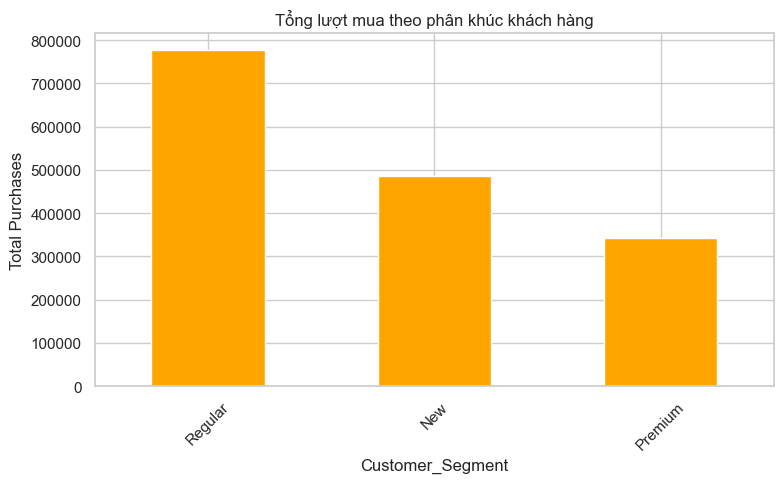

In [167]:
plt.figure(figsize=(8, 5))
segment_stats.plot(kind='bar', color='orange')
plt.title('Tổng lượt mua theo phân khúc khách hàng')
plt.ylabel('Total Purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- **Nhận xét:** Regular là phân khúc khách hàng lớn nhất, cho thấy doanh nghiệp có một nhóm khách hàng trung thành và thường xuyên mua sắm. New cũng chiếm một số lượng lớn, cho thấy có sự gia tăng trong việc thu hút khách hàng mới. Premium tuy có số lượng ít hơn nhưng vẫn đóng góp một phần đáng kể vào tổng lượt mua, cho thấy sự quan tâm đến các sản phẩm cao cấp.

#### B. Phân tích theo khu vực địa lý

##### Tổng số đơn hàng của các quốc gia

In [168]:
import plotly.express as px

# Tính số lượng đơn hàng theo quốc gia (đếm Transaction_ID duy nhất)
order_count_by_country = df.groupby('Country')['Transaction_ID'].nunique().reset_index()
order_count_by_country.columns = ['Country', 'Order_Count']

# Vẽ biểu đồ bản đồ
fig = px.choropleth(order_count_by_country,
                    locations='Country',
                    locationmode='country names',
                    color='Order_Count',
                    color_continuous_scale='Viridis',
                    title='Số lượng đơn hàng theo quốc gia')

fig.show()

Số lượng đơn hàng theo các quốc gia trong dữ liệu của bạn như sau:

USA: 94.491 đơn hàng

UK: 62.575 đơn hàng

Germany: 52.400 đơn hàng

Australia: 44.982 đơn hàng

Canada: 44.922 đơn hàng

Nhận xét:

Mỹ (USA) là quốc gia có số lượng đơn hàng lớn nhất, chiếm tỷ lệ rất cao so với các quốc gia khác.

Anh (UK), Đức (Germany), Úc (Australia) và Canada có số lượng đơn hàng khá gần nhau, từ khoảng 44 nghìn đến 62 nghìn đơn hàng.

Các quốc gia này đều là những thị trường chính, có thể là trọng điểm về khách hàng và doanh số.

##### Top 10 thành phố có doanh thu cao nhất

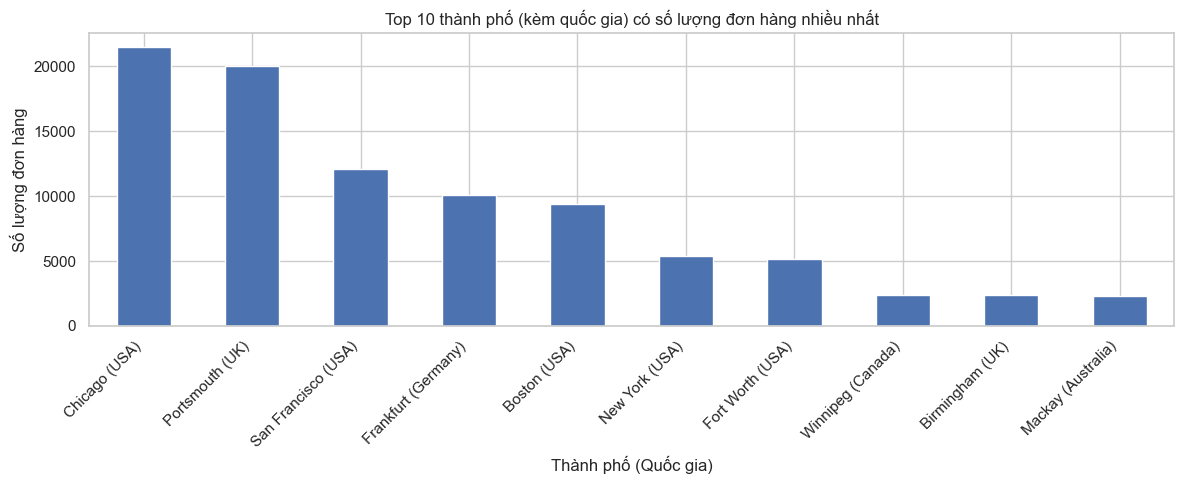

In [169]:
# Tạo cột mới kết hợp City và Country
df['City_Country'] = df['City'] + " (" + df['Country'] + ")"

# Top 10 city theo số lượng đơn hàng (đã gộp với quốc gia)
top10_city_order_counts_cc = df['City_Country'].value_counts().head(10)

# Top 10 city theo doanh thu (tổng Total_Amount) với City_Country
top10_city_revenue_cc = df.groupby('City_Country')['Total_Amount'].sum().sort_values(ascending=False).head(10)

# Vẽ biểu đồ số lượng đơn hàng theo City_Country
plt.figure(figsize=(12, 5))
top10_city_order_counts_cc.plot(kind='bar')
plt.title('Top 10 thành phố (kèm quốc gia) có số lượng đơn hàng nhiều nhất')
plt.xlabel('Thành phố (Quốc gia)')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Các thành phố đứng đầu về doanh thu tương ứng khá sát với bảng số lượng đơn hàng.

Chicago (USA) vừa có số lượng đơn hàng cao vừa có doanh thu lớn nhất, chứng tỏ thị trường rất mạnh.

Portsmouth (UK) và San Francisco (USA) cũng có doanh thu rất lớn, phù hợp với vị trí số lượng đơn hàng.

Một số thành phố như Plymouth (UK) có doanh thu cao nhưng không nằm trong top 10 về số lượng đơn hàng, thể hiện giá trị đơn hàng trung bình cao hơn.

Tổng doanh thu các thành phố này cũng phản ánh mức độ tiêu thụ lớn và đa dạng các phân khúc khách hàng.



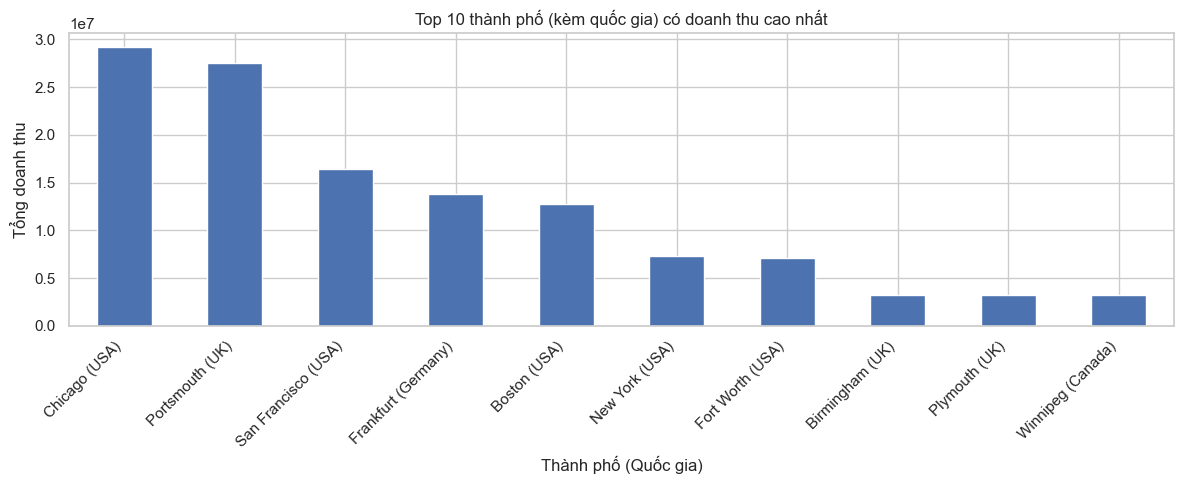

In [170]:
# Vẽ biểu đồ doanh thu theo City_Country
plt.figure(figsize=(12, 5))
top10_city_revenue_cc.plot(kind='bar')
plt.title('Top 10 thành phố (kèm quốc gia) có doanh thu cao nhất')
plt.xlabel('Thành phố (Quốc gia)')
plt.ylabel('Tổng doanh thu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Các thành phố đứng đầu về doanh thu tương ứng khá sát với bảng số lượng đơn hàng.

Chicago (USA) vừa có số lượng đơn hàng cao vừa có doanh thu lớn nhất lên tới 29,163,438.62, chứng tỏ thị trường rất mạnh.

Portsmouth (UK) và San Francisco (USA) cũng có doanh thu rất lớn, phù hợp với vị trí số lượng đơn hàng.

Một số thành phố như Plymouth (UK) có doanh thu cao nhưng không nằm trong top 10 về số lượng đơn hàng, thể hiện giá trị đơn hàng trung bình cao hơn.

Điều này cho thấy những thành phố này có thể là những thị trường trọng điểm với lượng khách hàng hoặc giao dịch lớn. Các thành phố như San Francisco, Boston, và New York cũng đóng góp đáng kể vào doanh thu, cho thấy đây là các thành phố có nhu cầu cao về sản phẩm hoặc dịch vụ. Các doanh nghiệp có thể tập trung vào các thành phố này để tối ưu hóa chiến lược tiếp thị và bán hàng.



##### So sánh doanh thu hàng theo Country

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\649037511.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




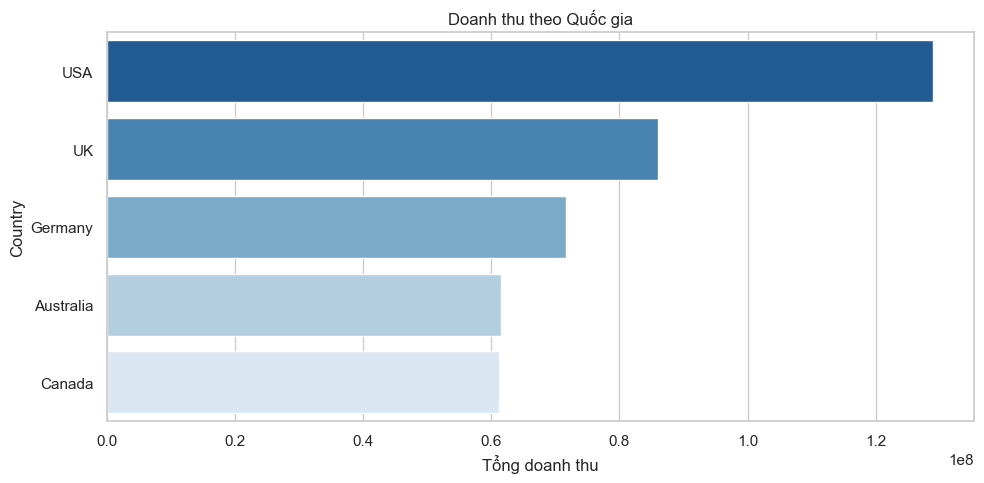

In [171]:
revenue_by_country = df.groupby('Country')['Total_Amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=revenue_by_country, y='Country', x='Total_Amount', palette='Blues_r')
plt.title('Doanh thu theo Quốc gia')
plt.xlabel('Tổng doanh thu')
plt.tight_layout()
plt.show()

1. Hoa Kỳ (USA):

- Là quốc gia có tổng doanh thu cao nhất, khoảng 128.85 triệu. 

- Đây là thị trường chính và quan trọng nhất trong tập dữ liệu, chiếm tỉ trọng lớn so với các quốc gia còn lại.

2. Vương quốc Anh (UK):

- Đứng thứ hai với doanh thu khoảng 86.07 triệu.

- Đây cũng là thị trường lớn, nhưng thấp hơn khoảng 33% so với Mỹ.

3. Đức (Germany):

- Doanh thu đứng thứ ba, khoảng 71.64 triệu.

- Cho thấy Đức là thị trường quan trọng ở châu Âu với mức doanh thu đáng kể.

4. Australia và Canada:

- Australia và Canada có doanh thu tương đương nhau, lần lượt khoảng 61.59 triệu và 61.24 triệu.

- Đây là các thị trường quan trọng khác nhưng thấp hơn Mỹ, Anh và Đức.



### 3. Phân tích giao dịch

#### A. Doanh thu & số lượng

##### Tổng doanh thu (Total_Amount) theo năm/tháng

In [172]:
revenue_by_year = df.groupby('Year')['Total_Amount'].sum()
print(revenue_by_year.apply(lambda x: f"{x:,.2f}").to_string())

Year
2023    342,048,237.35
2024     67,335,188.22


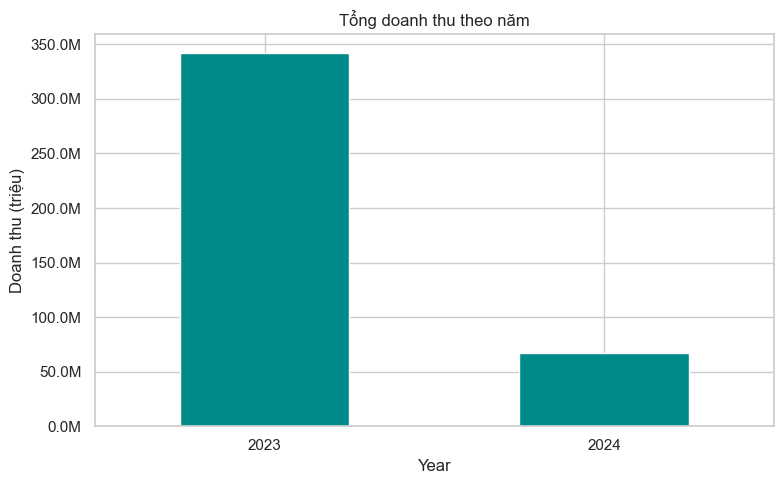

In [173]:
def format_millions(x, pos):
    return f'{x * 1e-6:.1f}M'

plt.figure(figsize=(8, 5))
revenue_by_year.plot(kind='bar', color='darkcyan')
plt.title('Tổng doanh thu theo năm')
plt.ylabel('Doanh thu (triệu)')
plt.xticks(rotation=0)

# Format trục y theo triệu
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))

plt.tight_layout()
plt.show()


In [174]:
min_date = df['Date'].min()
max_date = df['Date'].max()

min_date, max_date

(Timestamp('2023-03-01 00:00:00'), Timestamp('2024-02-29 00:00:00'))

Chúng ta có thể thấy doanh thu của năm 2024 thấp gấp nhiều lần so với năm 2023. Điều này đén từ yếu tố dữ liệu khi chỉ có 2 tháng của 2024 được thu thập.

##### Tổng số lượng đơn hàng theo tháng

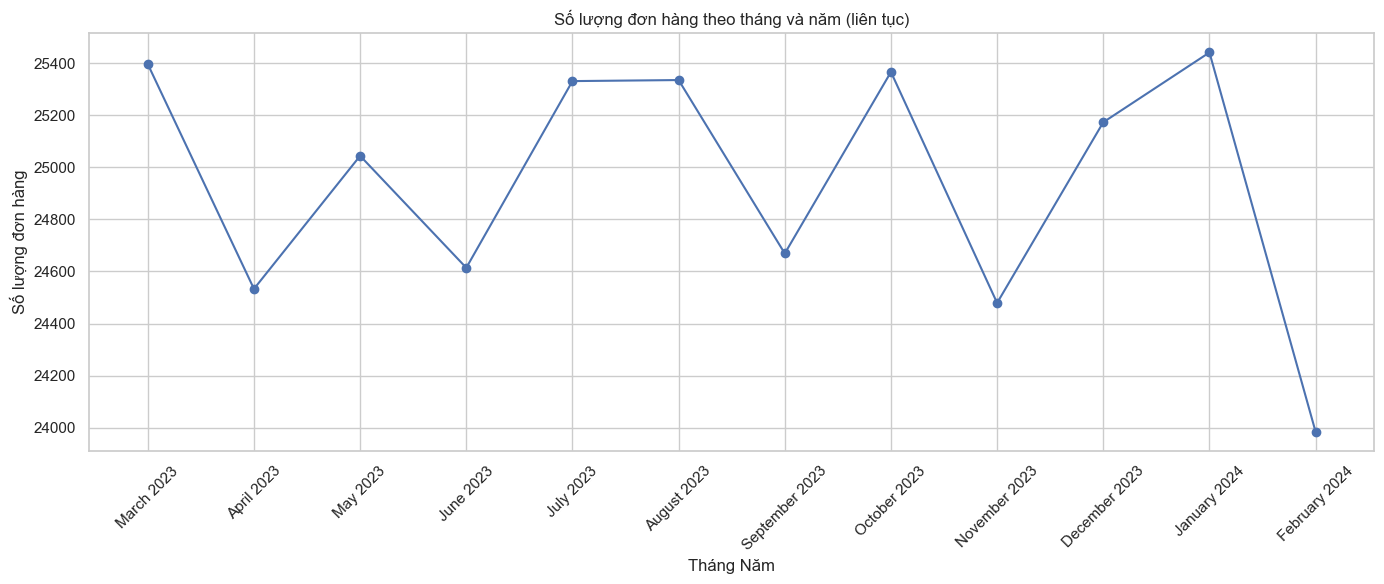

In [175]:
import matplotlib.pyplot as plt

# Định nghĩa lại thứ tự tháng
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
month_order_map = {month: i+1 for i, month in enumerate(month_order)}

# Thêm cột Month_Num cho dữ liệu gốc
df['Month_Num'] = df['Month'].map(month_order_map)

# Tạo cột Time_Index: số tháng liên tục tính từ tháng nhỏ nhất trong dữ liệu
min_year = df['Year'].min()
min_month = df[df['Year'] == min_year]['Month_Num'].min()

def time_index(row):
    return (row['Year'] - min_year) * 12 + (row['Month_Num'] - min_month + 1)

df['Time_Index'] = df.apply(time_index, axis=1)

# Tổng hợp số lượng đơn hàng và doanh thu theo Time_Index
orders_by_time = df.groupby('Time_Index').size().reset_index(name='Order_Count')
revenue_by_time = df.groupby('Time_Index')['Total_Amount'].sum().reset_index()

# Tạo nhãn trục x theo Time_Index
# Lấy cột Year và Month tương ứng với mỗi Time_Index
time_labels = df.groupby('Time_Index').agg({'Year':'first', 'Month':'first'}).reset_index()
time_labels['Label'] = time_labels['Month'] + ' ' + time_labels['Year'].astype(str)

# Vẽ biểu đồ số lượng đơn hàng
plt.figure(figsize=(14,6))
plt.plot(orders_by_time['Time_Index'], orders_by_time['Order_Count'], marker='o')
plt.xticks(ticks=time_labels['Time_Index'], labels=time_labels['Label'], rotation=45)
plt.title('Số lượng đơn hàng theo tháng và năm (liên tục)')
plt.xlabel('Tháng Năm')
plt.ylabel('Số lượng đơn hàng')
plt.grid(True)
plt.tight_layout()
plt.show()




Năm 2023

- Dữ liệu chỉ có từ tháng 3 đến tháng 12.

- Số lượng đơn hàng dao động quanh mức 24,400 đến 25,400 đơn hàng mỗi tháng, khá ổn định.

- Tháng 3: khoảng 25,400 đơn hàng, bắt đầu cao.

- Tháng 4 có giảm nhẹ so với tháng 3 (24,533).

- Từ tháng 5 đến tháng 10, số lượng đơn hàng khá ổn định, dao động quanh 24,600 - 25,300.

- Tháng 9 có giảm so với tháng 8 và tháng 10 (24,669 so với 25,335 và 25,366).

- Tháng 11 tiếp tục giảm nhẹ xuống 24,479 đơn hàng.

- Tháng 12 tăng nhẹ trở lại (25,173).

Năm 2024

- Dữ liệu chỉ có tháng 1 và 2.

- Tháng 1: 25,441 đơn hàng (không có dữ liệu, nên không so sánh được với  năm 2023).

- Tháng 2 giảm còn 23,984 đơn hàng, giảm khoảng 6% so với tháng 1.

Phân tích và phán đoán
- Năm 2023 có số lượng đơn hàng khá ổn định, dao động nhẹ qua các tháng, với một số tháng có giảm nhẹ (tháng 4, tháng 6, tháng 9, tháng 11).

- Năm 2024 bắt đầu với tháng 1 có số lượng đơn hàng cao tương đương hoặc hơn tháng 3 năm 2023, nhưng tháng 2 giảm đáng kể.

- Dữ liệu 2024 còn hạn chế nên chưa thể kết luận xu hướng cả năm, nhưng sự giảm ở tháng 2 cần được chú ý theo dõi.

##### Tổng doanh thu theo tháng 

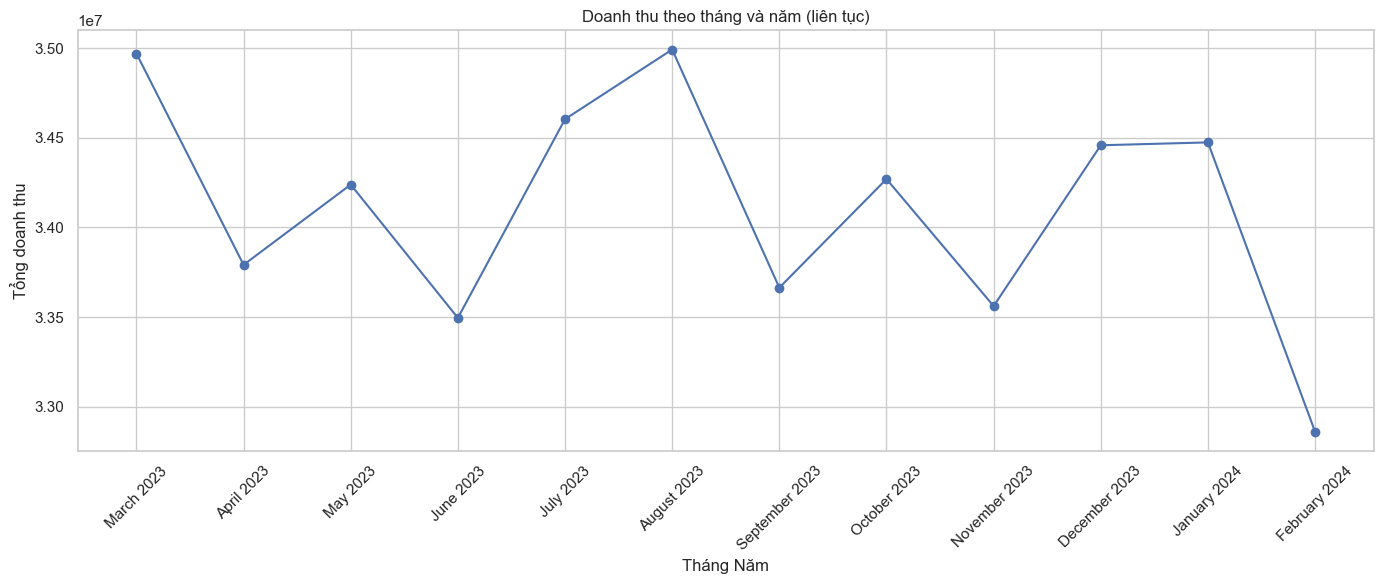

In [176]:
# Vẽ biểu đồ doanh thu
plt.figure(figsize=(14,6))
plt.plot(revenue_by_time['Time_Index'], revenue_by_time['Total_Amount'], marker='o')
plt.xticks(ticks=time_labels['Time_Index'], labels=time_labels['Label'], rotation=45)
plt.title('Doanh thu theo tháng và năm (liên tục)')
plt.xlabel('Tháng Năm')
plt.ylabel('Tổng doanh thu')
plt.grid(True)
plt.tight_layout()
plt.show()

Năm 2023

- Doanh thu dao động quanh mức từ khoảng 33 triệu đến gần 35 triệu mỗi tháng.

- Tháng 3 có doanh thu khoảng 34.97 triệu, sau đó giảm nhẹ vào tháng 4 (33.79 triệu).

- Doanh thu tăng nhẹ vào tháng 5 và 7, đạt khoảng 34.23 - 34.60 triệu.

- Tháng 8 đạt doanh thu cao nhất trong năm, khoảng 34.99 triệu.

- Tháng 9 và 11 có doanh thu giảm nhẹ so với các tháng liền trước, tương tự xu hướng giảm đơn hàng.

- Doanh thu tháng 12 phục hồi nhẹ lên khoảng 34.46 triệu.

Năm 2024

- Tháng 1 đạt doanh thu khoảng 34.47 triệu, tương đương với mức cao của các tháng trong năm 2023.

- Tháng 2 có doanh thu giảm xuống còn khoảng 32.86 triệu.

Phân tích tổng quát

- Doanh thu theo tháng có sự ổn định tương đối qua các tháng trong năm 2023, không có biến động lớn, tương tự với số lượng đơn hàng.

- Tháng 8 năm 2023 là tháng có doanh thu cao nhất, có thể do các chương trình khuyến mãi hoặc mùa vụ đặc biệt.

- Tháng 9 và 11 năm 2023 có sự giảm nhẹ, tương ứng với số lượng đơn hàng giảm.

- Năm 2024 mới chỉ có dữ liệu 2 tháng đầu năm, với tháng 2 giảm doanh thu so với tháng 1.



####  B. Theo sản phẩm

##### Phân bố theo Product_Category

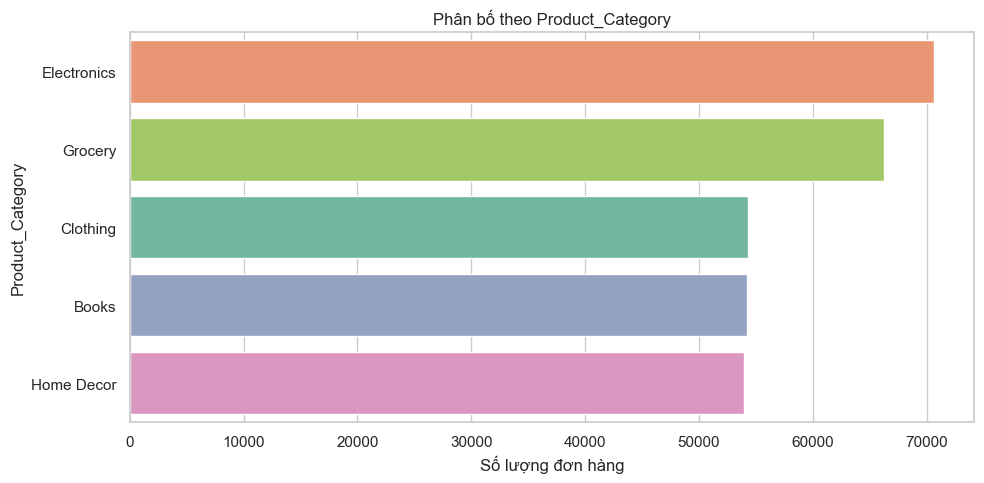

In [177]:
plt.figure(figsize=(10, 5))
sns.countplot(y='Product_Category', hue = 'Product_Category', data=df, order=df['Product_Category'].value_counts().index, palette='Set2')
plt.title('Phân bố theo Product_Category')
plt.xlabel('Số lượng đơn hàng')
plt.tight_layout()
plt.show()


- **Electronics** là nhóm sản phẩm có số lượng đơn hàng cao nhất.
- **Grocery** và **Clothing** cũng chiếm tỷ trọng lớn, lần lượt ở vị trí thứ hai và ba.
- Các nhóm **Books** và **Home Decor** có số lượng đơn hàng thấp hơn, nhưng vẫn ở mức tương đối cao.
- Nhìn chung, khách hàng có xu hướng mua nhiều sản phẩm điện tử và nhu yếu phẩm, cho thấy hành vi tiêu dùng tập trung vào các mặt hàng thiết yếu và công nghệ.

##### Phân bố theo Product_Brand

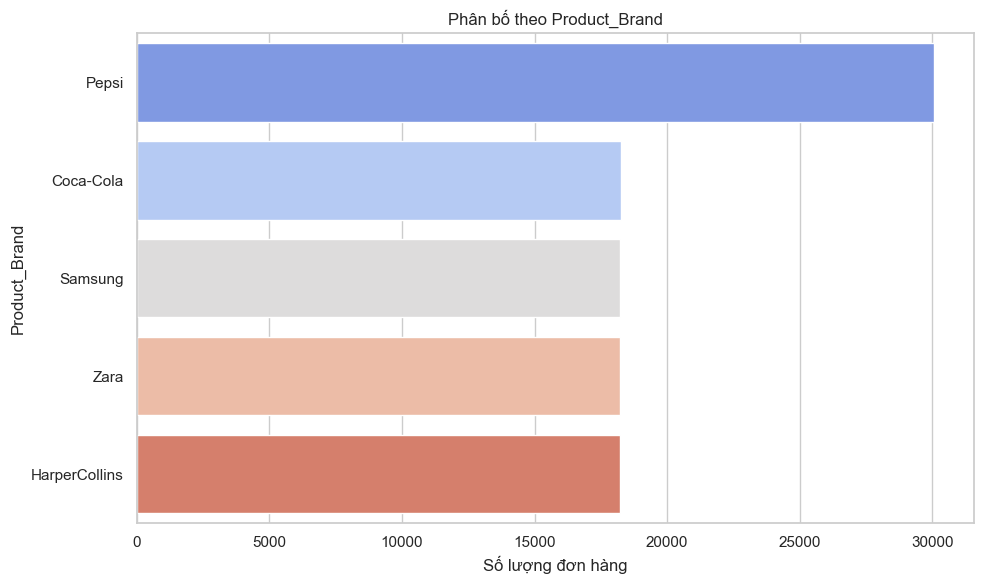

In [178]:
plt.figure(figsize=(10, 6))
top_brands = df['Product_Brand'].value_counts().head(5)
sns.barplot(y=top_brands.index, hue= top_brands.index, x=top_brands.values, palette='coolwarm')
plt.title('Phân bố theo Product_Brand')
plt.xlabel('Số lượng đơn hàng')
plt.tight_layout()
plt.show()

- **Pepsi** dẫn đầu về số lượng đơn hàng, vượt xa các thương hiệu còn lại.
- **Coca-Cola**, **Samsung**, và **Zara** có số đơn hàng gần tương đương nhau, thể hiện mức độ cạnh tranh cao.
- **HarperCollins** – một thương hiệu sách – cũng nằm trong top 5, cho thấy nhu cầu tiêu dùng văn hóa vẫn hiện diện rõ nét.
- Tổng thể, nhóm đồ uống và điện tử đang chiếm ưu thế trong hành vi mua sắm.

##### Phân bố theo Product_Type

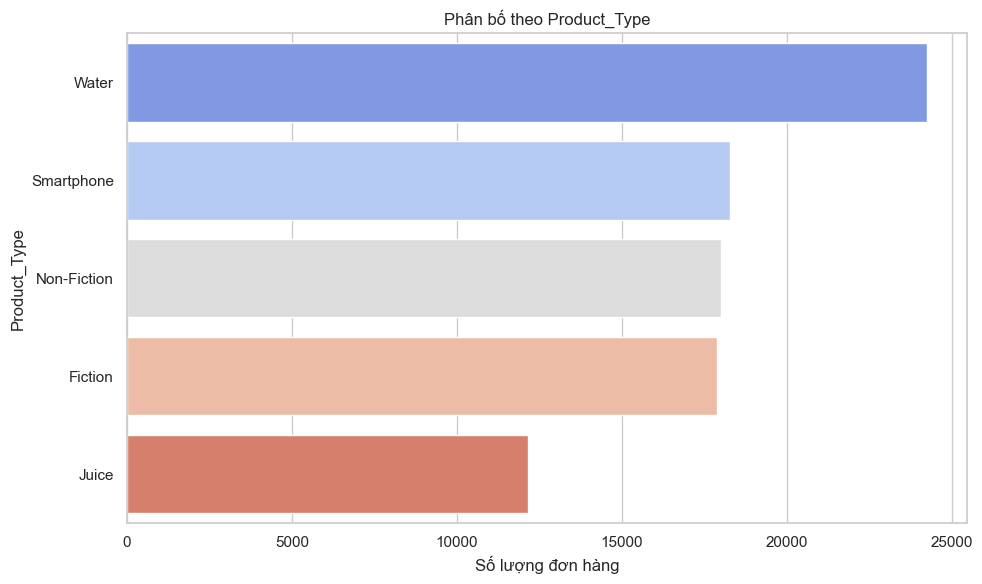

In [179]:
plt.figure(figsize=(10, 6))
top_type = df['Product_Type'].value_counts().head(5)
sns.barplot(y=top_type.index, hue= top_type.index, x=top_type.values, palette='coolwarm')
plt.title('Phân bố theo Product_Type')
plt.xlabel('Số lượng đơn hàng')
plt.tight_layout()
plt.show()

- **Nước uống (Water)** là loại sản phẩm phổ biến nhất, với số lượng đơn hàng cao nhất – phản ánh nhu cầu thiết yếu và tần suất tiêu thụ cao.
- **Smartphone** đứng thứ hai, cho thấy sức hút lớn từ các mặt hàng công nghệ.
- **Sách** (bao gồm *Non-Fiction* và *Fiction*) có số lượng đơn hàng tương đương, khẳng định nhu cầu ổn định với sản phẩm tri thức và giải trí.
- **Nước ép (Juice)** tuy là thực phẩm nhưng có lượng đơn hàng thấp nhất trong top 5 – có thể xem xét lại mức độ quảng bá hoặc phân phối.

###  4. Phân tích hành vi mua hàng

#### Phân bố phương thức thanh toán (Payment_Method)

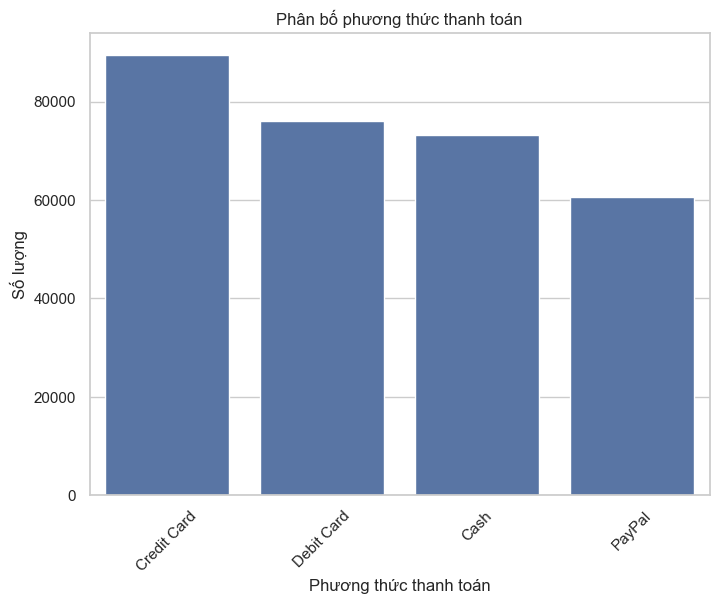

In [180]:
payment_method = df['Payment_Method'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=payment_method.index, y=payment_method.values)
plt.title('Phân bố phương thức thanh toán')
plt.xlabel('Phương thức thanh toán')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
plt.show()

Credit Card là phương thức thanh toán phổ biến nhất, có thể vì tính tiện lợi và sự phổ biến của việc sử dụng thẻ tín dụng trong giao dịch trực tuyến.

Debit Card và Cash là những phương thức thanh toán tiếp theo, phản ánh sự ưa chuộng của khách hàng đối với các hình thức thanh toán khác ngoài thẻ tín dụng.

PayPal có số lượng thấp hơn, có thể chỉ ra rằng không phải tất cả khách hàng đều ưa chuộng các dịch vụ thanh toán điện tử này.

#### Tình trạng đơn hàng (Order_Status)

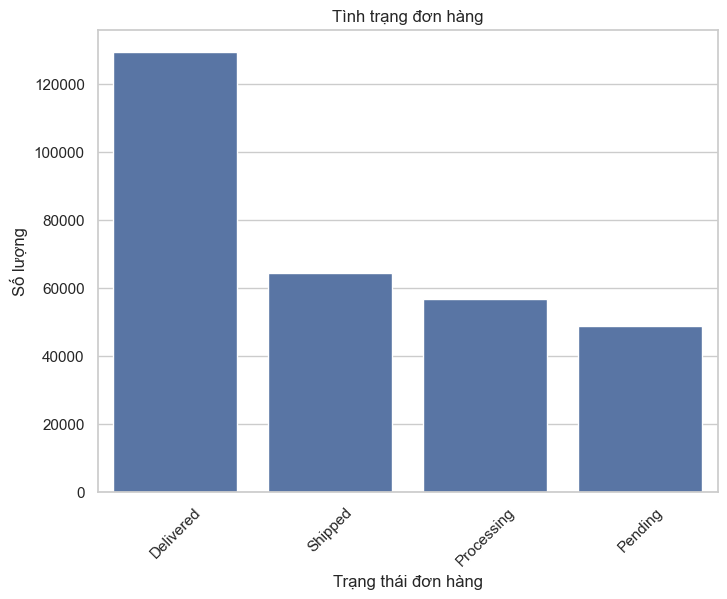

In [181]:
order_status = df['Order_Status'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=order_status.index, y=order_status.values)
plt.title('Tình trạng đơn hàng')
plt.xlabel('Trạng thái đơn hàng')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
plt.show()

Delivered chiếm số lượng lớn nhất, phản ánh sự hoàn thành và giao hàng thành công của các đơn hàng.

Shipped có thể là các đơn hàng đang trên đường giao.

Processing và Pending có thể là những đơn hàng đang trong trạng thái chờ xử lý hoặc chưa được hoàn tất.

Doanh nghiệp cần chú ý đến các đơn hàng ở trạng thái Pending và Processing, vì chúng có thể ảnh hưởng đến sự hài lòng của khách hàng nếu bị chậm trễ.

#### Mức độ đánh giá (Ratings) → xem khách hàng hài lòng không

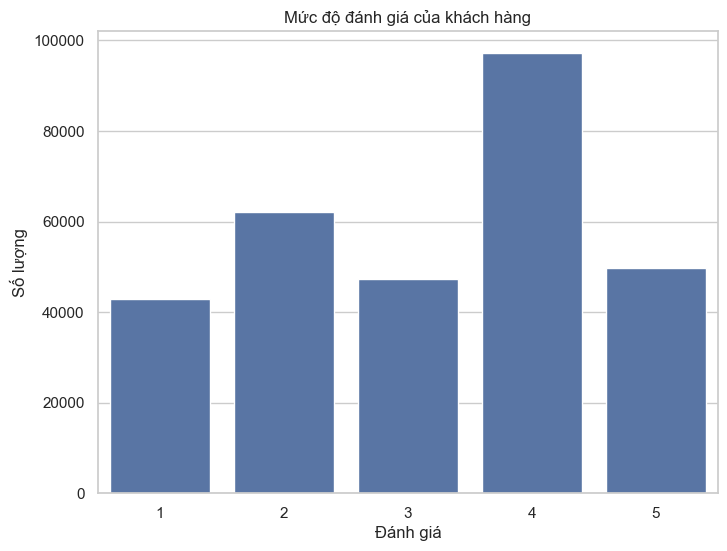

In [182]:
# Lọc bỏ các giá trị -1
filtered_ratings = df[df['Ratings'] != -1]

# Đếm số lượng đánh giá
ratings_count = filtered_ratings['Ratings'].value_counts().sort_index()

# Vẽ biểu đồ cột
plt.figure(figsize=(8, 6))
sns.barplot(x=ratings_count.index, y=ratings_count.values)
plt.title('Mức độ đánh giá của khách hàng')
plt.xlabel('Đánh giá')
plt.ylabel('Số lượng')
plt.show()

Đánh giá 4 và 5 sao chiếm tỷ lệ cao nhất, cho thấy khách hàng chủ yếu hài lòng với sản phẩm và dịch vụ.

Đánh giá 1 sao (phản hồi tiêu cực) cũng có tỷ lệ đáng kể, điều này có thể chỉ ra rằng có một số vấn đề liên quan đến chất lượng sản phẩm hoặc dịch vụ.

Phản hồi không có đánh giá (177 phản hồi) có thể là những khách hàng chưa đưa ra đánh giá sau khi sử dụng sản phẩm.

#### Feedback: thống kê các mức độ phản hồi (Excellent, Average, Bad)

In [183]:
feedback_counts = df['Feedback'].value_counts()

print(feedback_counts)

Feedback
Excellent      99838
Good           94280
Average        62111
Bad            42959
No Feedback      177
Name: count, dtype: int64


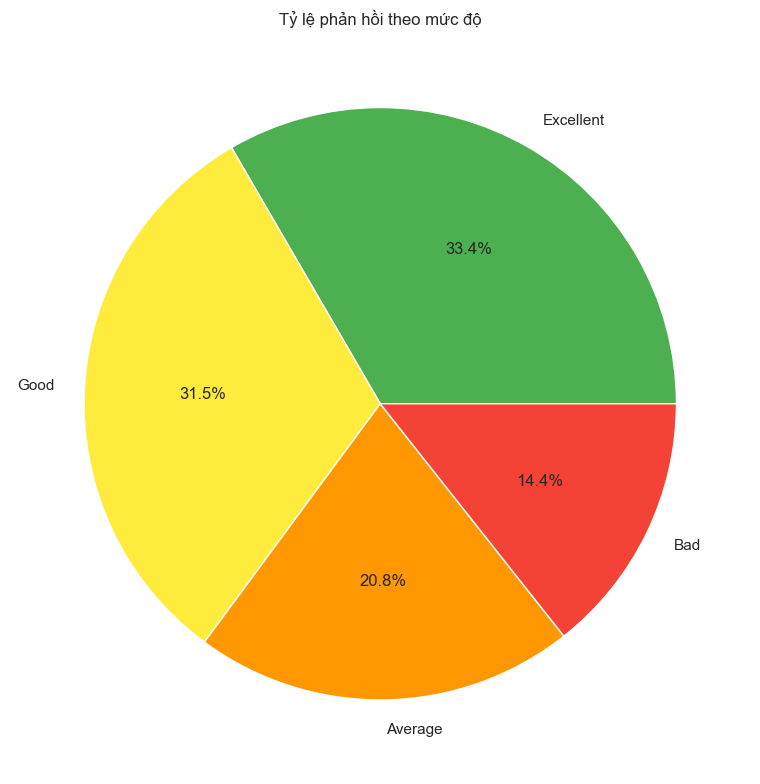

In [184]:
feedback_counts = {
    'Excellent': 99940,
    'Good': 94361,
    'Average': 62166,
    'Bad': 42989
}

# Vẽ biểu đồ tròn
plt.figure(figsize=(8, 8))
plt.pie(feedback_counts.values(), labels=feedback_counts.keys(), autopct='%1.1f%%', colors=['#4CAF50', '#FFEB3B', '#FF9800', '#F44336'])
plt.title('Tỷ lệ phản hồi theo mức độ')
plt.ylabel('')
plt.tight_layout()
plt.show()



Phản hồi "Excellent" chiếm tỷ lệ cao nhất, cho thấy khách hàng chủ yếu hài lòng với sản phẩm hoặc dịch vụ.

Phản hồi "Bad" cũng có tỷ lệ đáng kể, điều này có thể chỉ ra một số vấn đề trong trải nghiệm khách hàng cần được cải thiện, ví dụ như chất lượng sản phẩm hoặc dịch vụ giao hàng.

### 5. Phân tích vận chuyển

#### Tần suất các phương thức giao hàng (Shipping_Method)

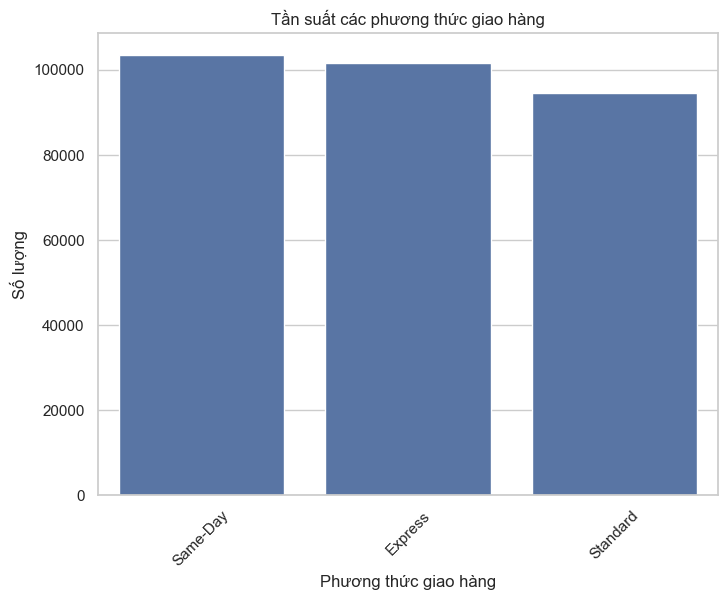

In [185]:
shipping_method = df['Shipping_Method'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=shipping_method.index, y=shipping_method.values)
plt.title('Tần suất các phương thức giao hàng')
plt.xlabel('Phương thức giao hàng')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
plt.show()

Same-Day và Express là hai phương thức giao hàng phổ biến nhất, phản ánh nhu cầu cao về giao hàng nhanh chóng, đặc biệt là trong các giao dịch trực tuyến nơi thời gian là yếu tố quan trọng.

Standard là phương thức giao hàng ít phổ biến hơn nhưng vẫn chiếm một phần lớn đơn hàng, cho thấy rằng một số khách hàng có thể chọn phương thức này vì giá thành thấp hơn hoặc không cần giao hàng nhanh.

Việc duy trì sự cân bằng giữa các phương thức giao hàng là quan trọng để đáp ứng nhu cầu đa dạng của khách hàng.

#### Phân tích vận chuyển theo khu vực → để cải thiện logistics

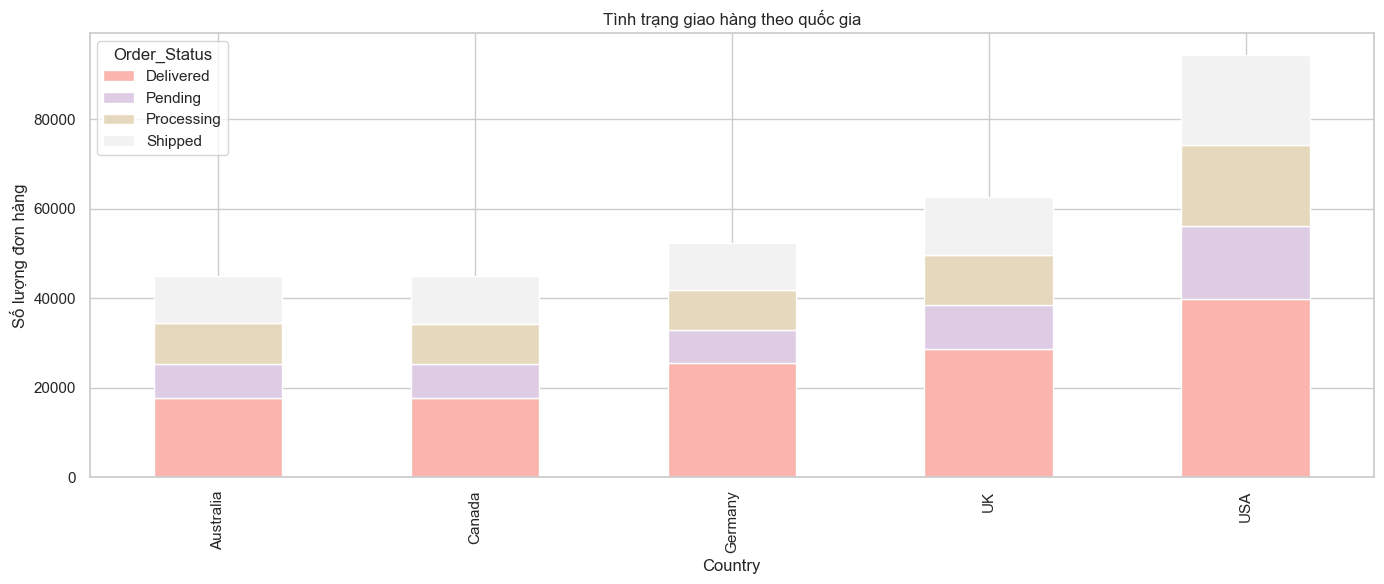

In [186]:
delivery_by_country = df.groupby(['Country', 'Order_Status']).size().unstack().fillna(0)

delivery_by_country.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Pastel1')
plt.title('Tình trạng giao hàng theo quốc gia')
plt.xlabel('Country')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


USA có số lượng đơn hàng giao thành công lớn nhất, điều này phản ánh sự phổ biến của dịch vụ tại thị trường Bắc Mỹ.

UK và Germany có số lượng đơn hàng Shipped lớn, cho thấy sự mạnh mẽ của thị trường tại các quốc gia này.

Các quốc gia như Australia và Canada có số lượng đơn hàng ở trạng thái Pending và Processing cao, điều này có thể chỉ ra rằng công tác giao hàng ở những quốc gia này có thể gặp phải một số thách thức về logistics hoặc sự chậm trễ trong việc xử lý đơn hàng.

Doanh nghiệp cần cải thiện quy trình vận chuyển ở những quốc gia có số lượng đơn hàng Pending hoặc Processing cao để tăng cường hiệu quả và sự hài lòng của khách hàng.

# Kể chuyện về dữ liệu

**Mở đầu**

- Trong thời đại hiện đại, khi thị trường tiêu dùng trở nên phong phú và khách hàng đứng trước hàng loạt sự lựa chọn, việc cạnh tranh trong ngành bán lẻ chưa bao giờ khốc liệt đến thế. Không chỉ cần có sản phẩm chất lượng hay mức giá cạnh tranh, các doanh nghiệp còn phải thực sự hiểu rõ khách hàng của mình – từ thói quen mua sắm, sở thích tiêu dùng, cho đến hành vi trong từng giai đoạn hành trình mua hàng.

- Trong bối cảnh đó, dữ liệu trở thành vũ khí chiến lược. Bộ dữ liệu gồm gần 300.000 giao dịch bán lẻ – chứa thông tin về khách hàng (tuổi, giới tính, thu nhập, phân khúc), sản phẩm (danh mục, thương hiệu, loại), và giao dịch (ngày mua, số lượng, số tiền, phương thức thanh toán, vận chuyển) – không chỉ đơn thuần là những con số, mà là nguồn tri thức quý giá để khám phá cách cá nhân hóa trải nghiệm, tối ưu hóa doanh thu và nâng cao khả năng giữ chân khách hàng trong cuộc đua không khoan nhượng này.

**Đặt vấn đề**

Doanh thu tổng (cột Total_Amount) là chỉ số quan trọng, nhưng câu hỏi đặt ra là: Làm thế nào để tăng doanh thu trong bối cảnh khách hàng có thể thay đổi thói quen mua sắm? Cụ thể, các yếu tố như danh mục sản phẩm bán chạy, thời điểm mua sắm, hoặc trải nghiệm giao dịch (vận chuyển, thanh toán) ảnh hưởng thế nào đến doanh thu? Nếu không nhận diện được các điểm mạnh và điểm yếu trong chiến lược bán lẻ, doanh nghiệp có thể bỏ lỡ cơ hội tăng trưởng hoặc mất khách hàng vào tay đối thủ.

***Hiệu suất của danh mục sản phẩm:***

Cột Product_Category, Product_Brand, và Product_Type cho thấy một số danh mục (như điện tử hoặc thời trang) có thể đóng góp doanh thu lớn, nhưng các danh mục khác (như đồ gia dụng) có thể có tỷ lệ mua thấp hơn. Nếu tồn kho tập trung vào các sản phẩm kém hiệu quả, doanh thu sẽ bị ảnh hưởng.
Đánh giá thấp (Ratings) hoặc phản hồi tiêu cực (Feedback) về sản phẩm có thể làm giảm doanh số, đặc biệt với các thương hiệu ít nổi tiếng.

**Doanh thu không phân bổ đồng đều giữa các danh mục**
- Biểu đồ tổng doanh thu theo Product_Category cho thấy một số danh mục Electronics và Grocery đang chiếm tỷ trọng lớn trong tổng doanh thu, trong khi các danh mục như Home Decor hoặc Books có đóng góp khá khiêm tốn. Điều này cho thấy không phải danh mục nào cũng mang lại giá trị tương xứng, và doanh nghiệp cần tập trung nguồn lực vào các danh mục chủ lực để tối ưu hiệu quả kinh doanh.

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\1668822341.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




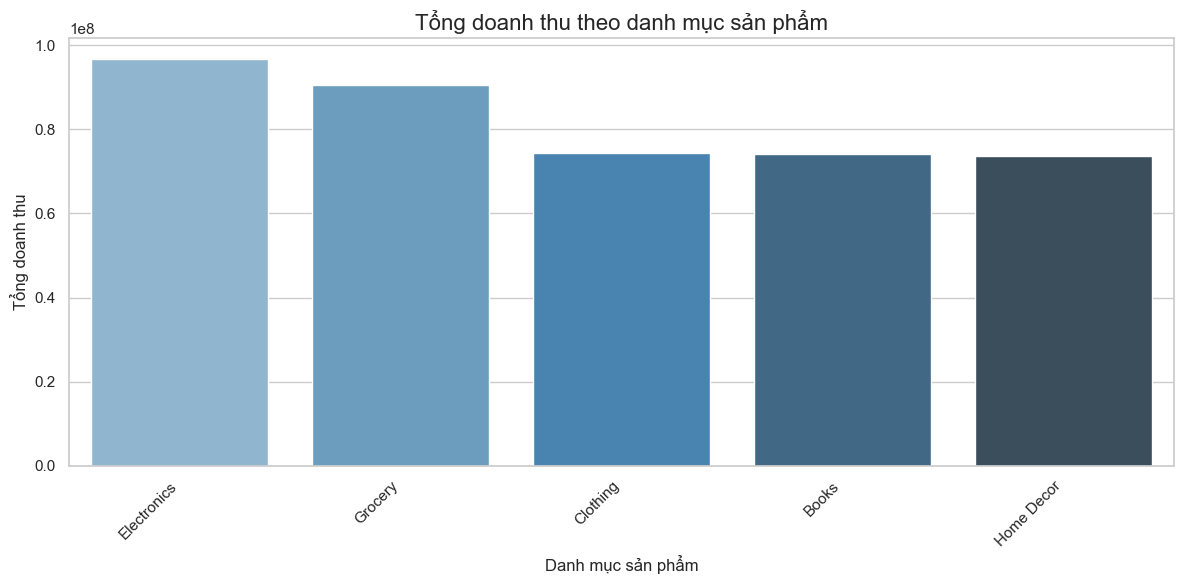

In [187]:
# Tính tổng doanh thu theo từng danh mục sản phẩm
category_revenue = df.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=False).reset_index()

# Thiết lập style trực quan
sns.set(style="whitegrid")

# Vẽ biểu đồ cột
plt.figure(figsize=(12, 6))
sns.barplot(data=category_revenue, x='Product_Category', y='Total_Amount', palette='Blues_d')

# Thêm nhãn và tiêu đề
plt.xticks(rotation=45, ha='right')
plt.title('Tổng doanh thu theo danh mục sản phẩm', fontsize=16)
plt.xlabel('Danh mục sản phẩm', fontsize=12)
plt.ylabel('Tổng doanh thu', fontsize=12)
plt.tight_layout()
plt.show()

**Sự chênh lệch giữa các thương hiệu trong cùng danh mục**
- Khi phân tích tổng doanh thu theo Product_Brand, có thể thấy rõ sự khác biệt giữa các thương hiệu. Một số thương hiệu dẫn đầu mang lại doanh thu cao như Pepsi, Samsung, trong khi nhiều thương hiệu còn lại có doanh số khá thấp (Mitsubhisi, BlueStar). Điều này cho thấy hiệu suất thương hiệu không đồng đều, và việc duy trì nhiều thương hiệu kém hiệu quả có thể gây lãng phí tài nguyên kho bãi hoặc ngân sách tiếp thị.

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\3584458273.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




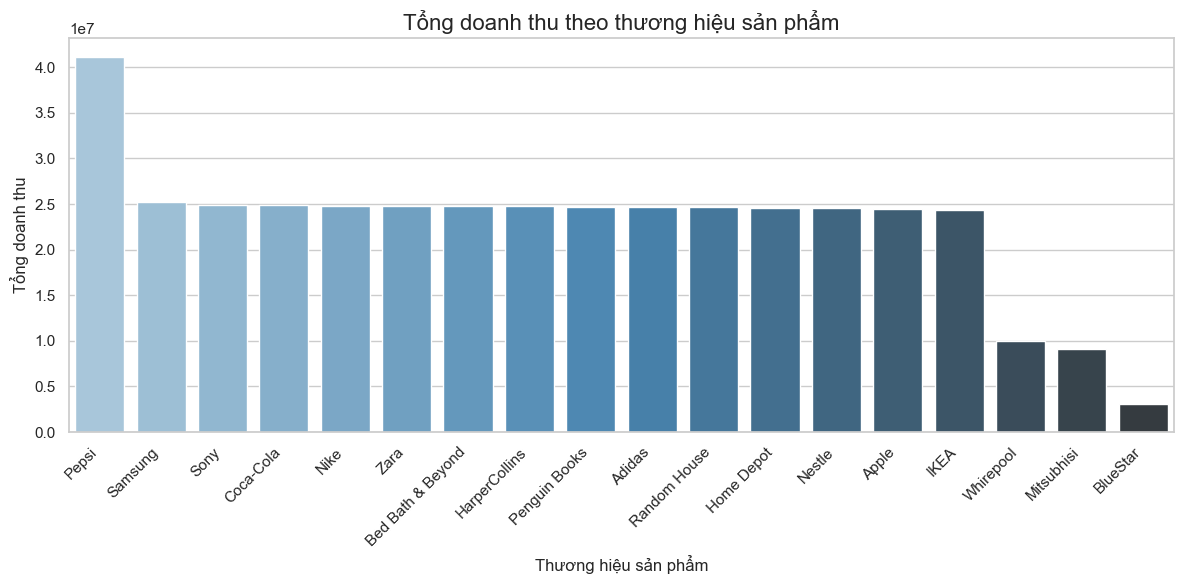

In [188]:
brand_revenue = df.groupby('Product_Brand')['Total_Amount'].sum().sort_values(ascending=False).reset_index()

# Thiết lập style trực quan
sns.set(style="whitegrid")

# Vẽ biểu đồ cột
plt.figure(figsize=(12, 6))
sns.barplot(data=brand_revenue, x='Product_Brand', y='Total_Amount', palette='Blues_d')

# Thêm nhãn và tiêu đề
plt.xticks(rotation=45, ha='right')
plt.title('Tổng doanh thu theo thương hiệu sản phẩm', fontsize=16)
plt.xlabel('Thương hiệu sản phẩm', fontsize=12)
plt.ylabel('Tổng doanh thu', fontsize=12)
plt.tight_layout()
plt.show()

**Không phải loại sản phẩm nào cũng tạo ra giá trị cao**
- Phân tích theo Product_Type tiếp tục làm rõ sự khác biệt về hiệu quả giữa các loại sản phẩm trong cùng danh mục. Một số loại sản phẩm được khách hàng ưu tiên và mang về doanh thu lớn (Water, Smartphone), trong khi nhiều loại khác có sức tiêu thụ thấp (Snack, BlueStar AC). Đây là cơ sở để tái cấu trúc danh mục sản phẩm và ưu tiên các mặt hàng có tỷ suất lợi nhuận tốt.

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\3985105287.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




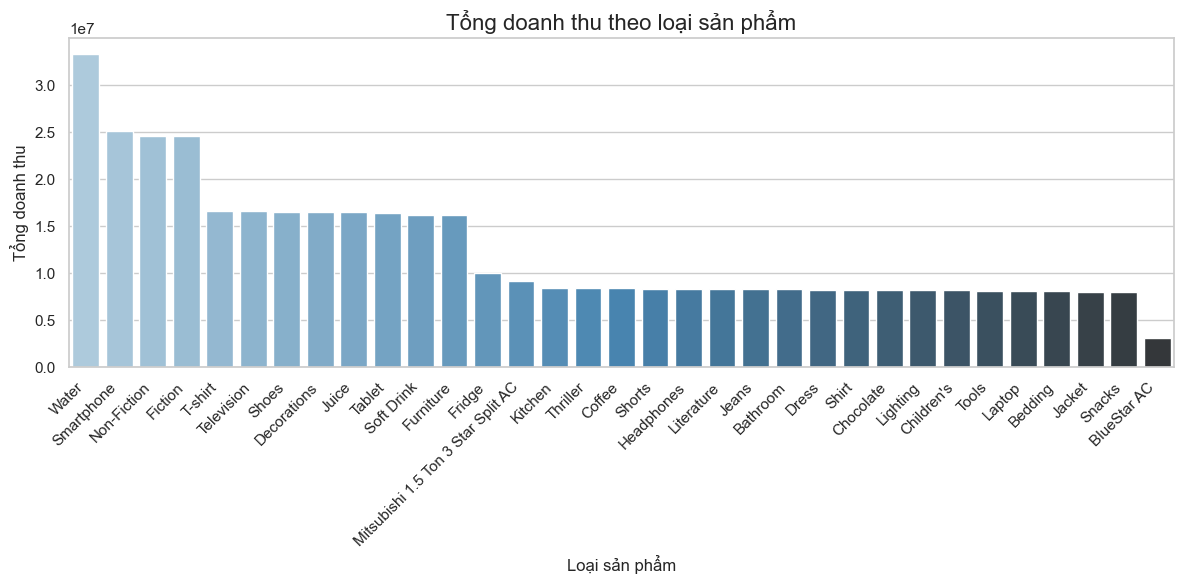

In [189]:
productType_revenue = df.groupby('Product_Type')['Total_Amount'].sum().sort_values(ascending=False).reset_index()

# Thiết lập style trực quan
sns.set(style="whitegrid")

# Vẽ biểu đồ cột
plt.figure(figsize=(12, 6))
sns.barplot(data=productType_revenue, x='Product_Type', y='Total_Amount', palette='Blues_d')

# Thêm nhãn và tiêu đề
plt.xticks(rotation=45, ha='right')
plt.title('Tổng doanh thu theo loại sản phẩm', fontsize=16)
plt.xlabel('Loại sản phẩm', fontsize=12)
plt.ylabel('Tổng doanh thu', fontsize=12)
plt.tight_layout()
plt.show()

**Chất lượng sản phẩm ảnh hưởng trực tiếp đến hành vi mua sắm**
- Biểu đồ số lượng giao dịch theo Ratings chỉ ra rằng phần lớn các giao dịch tập trung vào những sản phẩm có đánh giá cao (từ 4 đến 5 sao). Ngược lại, sản phẩm có đánh giá thấp có rất ít giao dịch. Điều này cho thấy uy tín và chất lượng sản phẩm có ảnh hưởng mạnh đến quyết định mua, đặc biệt đối với các thương hiệu chưa có độ nhận diện cao.

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\3724403645.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




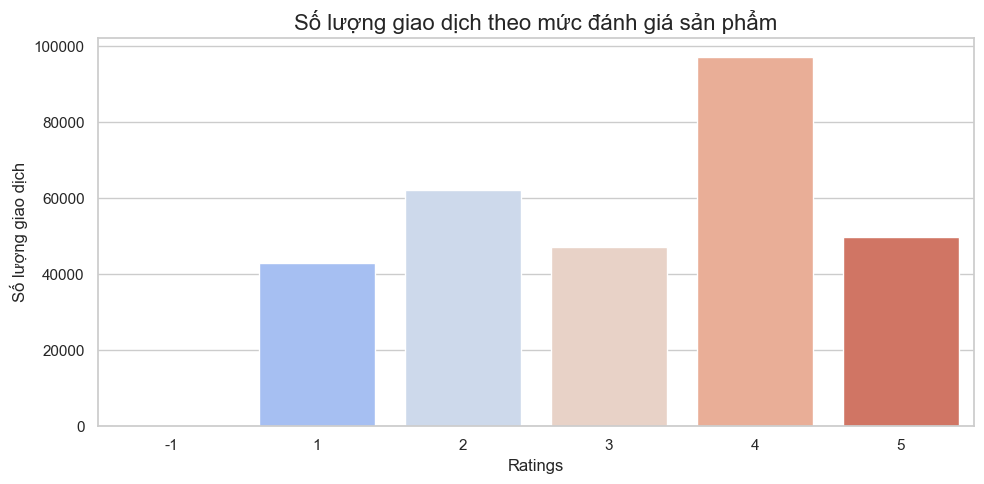

In [190]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Ratings', palette='coolwarm')

plt.title('Số lượng giao dịch theo mức đánh giá sản phẩm', fontsize=16)
plt.xlabel('Ratings', fontsize=12)
plt.ylabel('Số lượng giao dịch', fontsize=12)
plt.tight_layout()
plt.show()


***Trải nghiệm khách hàng và vận hành:***

**Phương thức giao hàng ảnh hưởng đến sự hài lòng và quyết định mua**
- Khách hàng hiện có nhiều lựa chọn về phương thức giao hàng như Standard, Express, hay Same-Day, phản ánh sự đa dạng trong nhu cầu nhận hàng. Tuy nhiên, nếu một phương thức phổ biến nhưng thiếu ổn định – như giao chậm hoặc thiếu chính xác – sẽ làm giảm chất lượng trải nghiệm và ảnh hưởng tiêu cực đến doanh thu. Thực tế, Same-Day đang dẫn đầu về tổng doanh thu (hơn 141 triệu), cho thấy tốc độ là yếu tố quan trọng. Do đó, việc đảm bảo hiệu quả cho các phương thức giao hàng nhanh là ưu tiên cần thiết để giữ chân khách hàng và tối ưu hóa lợi nhuận.

  Shipping_Method  Total_Amount
0        Same-Day  1.413055e+08
1         Express  1.389499e+08
2        Standard  1.291281e+08


C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\1874353528.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




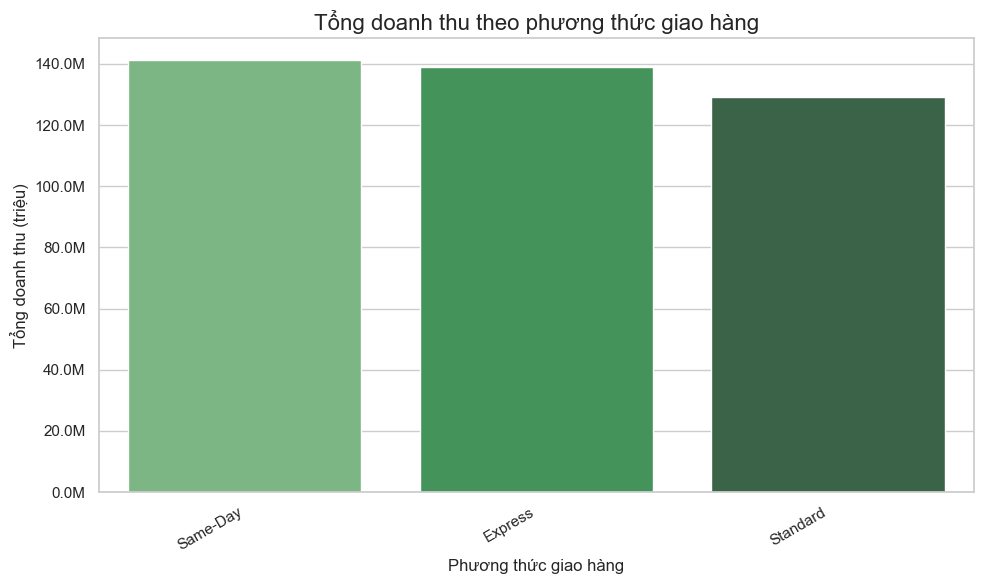

In [191]:
# Tính tổng doanh thu theo phương thức giao hàng
shipping_revenue = df.groupby('Shipping_Method')['Total_Amount'].sum().sort_values(ascending=False).reset_index()
print(shipping_revenue)
# Thiết lập style
sns.set(style="whitegrid")

# Hàm định dạng: chia giá trị cho 1 triệu và thêm chữ 'tr'
def format_million(x, _):
    return f'{x/1_000_000:.1f}M'  # hoặc dùng 'tr' nếu là VND: f'{x/1_000_000:.1f} tr'

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=shipping_revenue, x='Shipping_Method', y='Total_Amount', palette='Greens_d')

# Định dạng trục Y
ax.yaxis.set_major_formatter(FuncFormatter(format_million))

# Thêm nhãn và tiêu đề
plt.title('Tổng doanh thu theo phương thức giao hàng', fontsize=16)
plt.xlabel('Phương thức giao hàng', fontsize=12)
plt.ylabel('Tổng doanh thu (triệu)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Phương thức thanh toán có thể tạo ra rào cản mua sắm**
- Sự đa dạng trong phương thức thanh toán phản ánh thói quen và nhu cầu khác nhau của khách hàng. Credit Card tạo ra doanh thu cao nhất với hơn 122 triệu, tiếp theo là Debit Card và Cash, trong khi PayPal có doanh thu thấp hơn đáng kể (khoảng 82 triệu). Những con số này cho thấy các phương thức hiện đại như thẻ tín dụng đang được ưa chuộng hơn, đặc biệt với nhóm khách hàng trẻ. Ngược lại, nếu phương thức thanh toán không phù hợp hoặc gây bất tiện, khách hàng có thể từ bỏ đơn hàng. Vì vậy, phân tích doanh thu theo từng hình thức thanh toán giúp doanh nghiệp tối ưu trải nghiệm và giảm thiểu rủi ro mất đơn.

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\3027233278.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




  Payment_Method  Total_Amount
0    Credit Card  1.224486e+08
1     Debit Card  1.041256e+08
2           Cash  1.000790e+08
3         PayPal  8.273029e+07


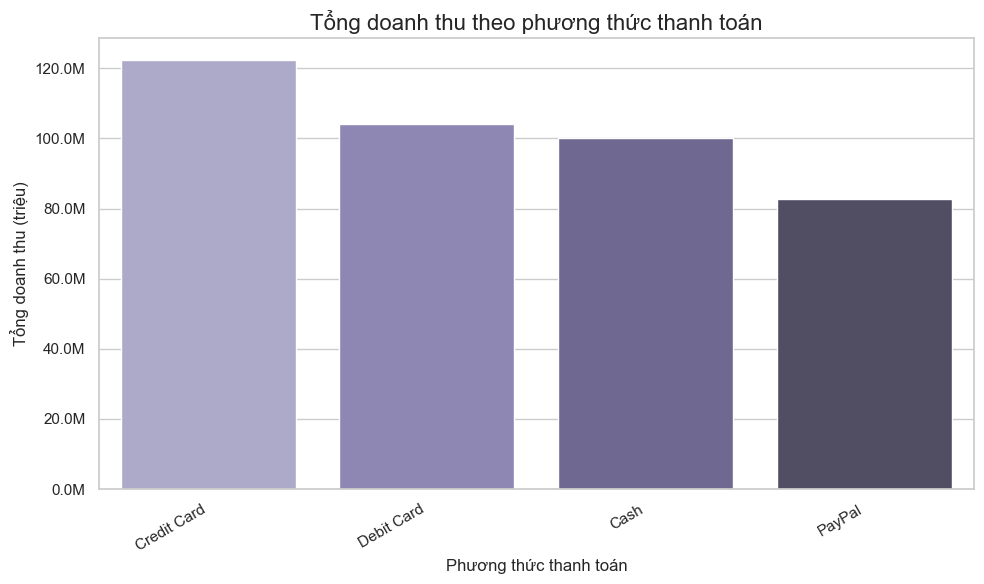

In [192]:
# Tính tổng doanh thu theo phương thức thanh toán
payment_revenue = df.groupby('Payment_Method')['Total_Amount'].sum().sort_values(ascending=False).reset_index()
print(payment_revenue)
# Thiết lập style
sns.set(style="whitegrid")

# Hàm định dạng số theo triệu
def format_million(x, _):
    return f'{x / 1_000_000:.1f}M'

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=payment_revenue, x='Payment_Method', y='Total_Amount', palette='Purples_d')

# Định dạng trục Y
ax.yaxis.set_major_formatter(FuncFormatter(format_million))

# Nhãn và tiêu đề
plt.title('Tổng doanh thu theo phương thức thanh toán', fontsize=16)
plt.xlabel('Phương thức thanh toán', fontsize=12)
plt.ylabel('Tổng doanh thu (triệu)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Tình trạng đơn hàng phản ánh hiệu quả vận hành**
- Trạng thái đơn hàng phản ánh mức độ hiệu quả trong quá trình vận hành. Dữ liệu cho thấy phần lớn đơn hàng đã được giao thành công (Delivered) với hơn 129.000 đơn, tuy nhiên vẫn còn hàng chục nghìn đơn ở các trạng thái chưa hoàn tất như Shipped (64.482), Processing (56.761) và Pending (48.709). Dù chưa xuất hiện trạng thái hủy, tỷ lệ đơn chưa hoàn tất vẫn cho thấy tiềm ẩn rủi ro trong khâu xử lý hoặc giao hàng. Việc theo dõi và tối ưu tỷ lệ đơn hoàn tất là yếu tố then chốt để nâng cao trải nghiệm khách hàng và bảo vệ doanh thu.

Order_Status
Delivered     129499
Shipped        64437
Processing     56743
Pending        48686
Name: count, dtype: int64


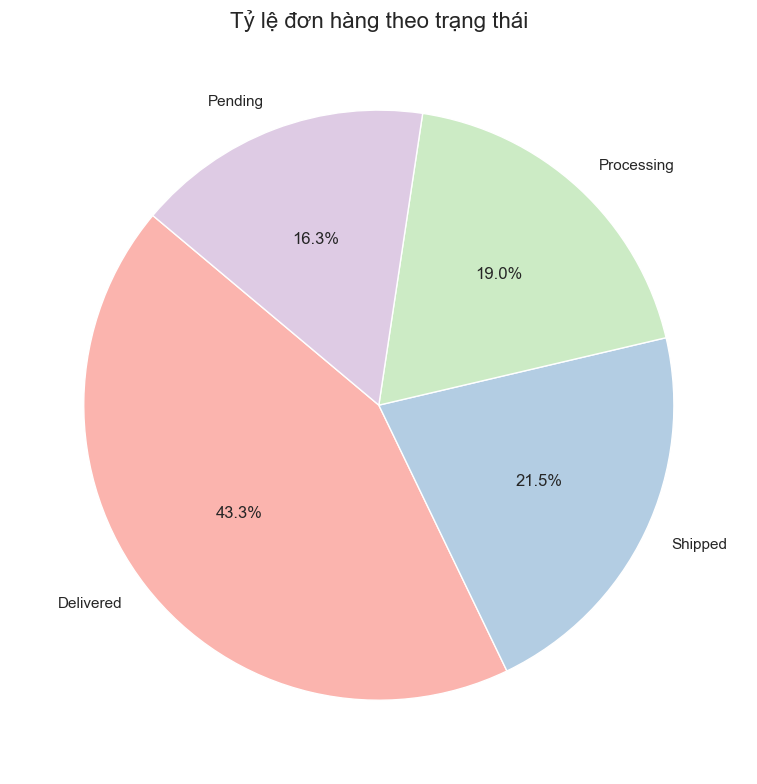

In [193]:
# Đếm số lượng đơn hàng theo trạng thái
order_counts = df['Order_Status'].value_counts()
print(order_counts)
# Vẽ biểu đồ tròn
plt.figure(figsize=(8, 8))
plt.pie(order_counts, labels=order_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)

# Tiêu đề
plt.title('Tỷ lệ đơn hàng theo trạng thái', fontsize=16)
plt.tight_layout()
plt.show()

**Phản hồi và đánh giá là chỉ báo cho trải nghiệm tổng thể**
- Các cột Feedback và Ratings không chỉ phản ánh cảm nhận của khách hàng về sản phẩm, mà còn nói lên toàn bộ trải nghiệm mua sắm – từ khâu lựa chọn sản phẩm, thanh toán, đến giao nhận. Những phản hồi tiêu cực thường gắn liền với các vấn đề vận hành chưa tốt, và nếu không cải thiện, điều này sẽ ảnh hưởng trực tiếp đến doanh số và lòng trung thành của khách hàng.

C:\Users\FPTSHOP\AppData\Local\Temp\ipykernel_11444\965495762.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




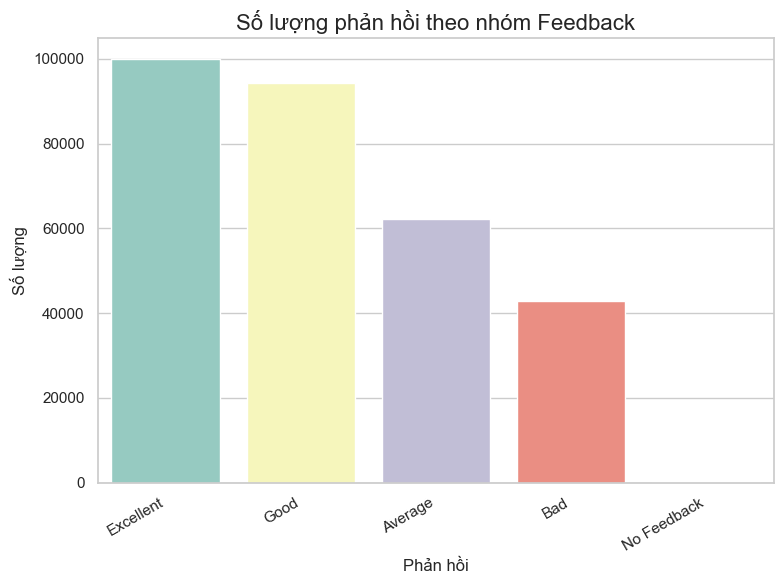

In [194]:
# Thiết lập style
sns.set(style="whitegrid")

# Vẽ biểu đồ countplot
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Feedback', palette='Set3', order=df['Feedback'].value_counts().index)

# Nhãn và tiêu đề
plt.title('Số lượng phản hồi theo nhóm Feedback', fontsize=16)
plt.xlabel('Phản hồi', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Kết luận và hướng giải quyết**

Để tăng doanh thu trong ngành bán lẻ, doanh nghiệp cần thực hiện các chiến lược sau:

***Cá nhân hóa trải nghiệm theo phân khúc khách hàng:***

Phân tích dữ liệu từ Customer_Segment, Age, và Income để tạo các chương trình khuyến mãi phù hợp. Ví dụ, cung cấp ưu đãi cho sản phẩm thời trang dành cho khách hàng trẻ hoặc giảm giá sản phẩm gia dụng cho khách hàng lớn tuổi.
Sử dụng dữ liệu để xây dựng chương trình khách hàng thân thiết, tập trung vào các nhóm chi tiêu cao hoặc mua sắm thường xuyên.
***Tối ưu hóa danh mục sản phẩm:***

Xác định danh mục sản phẩm có doanh thu cao nhất (Product_Category) và ưu tiên quảng bá chúng. Đồng thời, đánh giá các danh mục kém hiệu quả để cải thiện giá bán, chất lượng, hoặc chiến lược tiếp thị.
Đảm bảo các sản phẩm từ thương hiệu uy tín (Product_Brand) được ưu tiên trưng bày hoặc quảng cáo để tăng độ tin cậy.

***Tận dụng thời điểm mua sắm cao điểm:***

Phân tích dữ liệu theo Month và Day để xác định các thời điểm doanh thu cao (ví dụ: dịp lễ hoặc cuối tuần). Triển khai các chiến dịch giảm giá, flash sale, hoặc sự kiện tại cửa hàng vào những thời điểm này.
Đối với các tháng thấp điểm, sử dụng các chương trình kích cầu như giảm giá sâu hoặc combo sản phẩm để duy trì doanh thu.

***Cải thiện trải nghiệm khách hàng:***

Dựa trên Feedback và Ratings, xác định các điểm yếu trong quy trình bán hàng (ví dụ: giao hàng chậm, sản phẩm lỗi). Tối ưu hóa Shipping_Method bằng cách hợp tác với các đối tác vận chuyển đáng tin cậy.
Đa dạng hóa Payment_Method (ví dụ: thêm ví điện tử, trả góp) để đáp ứng nhu cầu của khách hàng.
Nếu có cửa hàng vật lý, đảm bảo trải nghiệm tại cửa hàng (như trưng bày sản phẩm, thái độ nhân viên) được cải thiện dựa trên phản hồi.

***Ứng dụng phân tích dữ liệu:***

Sử dụng các công cụ trực quan hóa để phân tích doanh thu theo danh mục, thời gian, hoặc phân khúc khách hàng. Nếu bạn muốn, tôi có thể tạo biểu đồ (ví dụ: doanh thu theo tháng hoặc danh mục sản phẩm) bằng cách mở canvas hoặc viết code Python với pandas.
Phân tích sâu hơn để dự đoán xu hướng mua sắm hoặc xác định các sản phẩm có tiềm năng tăng trưởng.
Bằng cách giải quyết các nguyên nhân trên, doanh nghiệp bán lẻ có thể tăng doanh thu, cải thiện lòng trung thành của khách hàng, và cạnh tranh hiệu quả hơn. Nếu bạn muốn tôi phân tích chi tiết hơn (ví dụ: tính toán doanh thu theo danh mục, phân khúc, hoặc tạo biểu đồ), hãy cung cấp thêm yêu cầu cụ thể!

# Xây dựng mô hình

## Mô hình KMeans phân cụm khách hàng 

### Chọn ra các đặc trưng

In [195]:
features = ['Total_Purchases', 'Total_Amount', 'Age', 'Income', 'Ratings']
df_cluster = df[features]

### Chuẩn hóa dữ liệu 

In [196]:
df_cluster = pd.get_dummies(df_cluster, columns=['Income'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster) 

df_cluster

,Total_Purchases,Total_Amount,Age,Ratings,Income_High,Income_Low,Income_Medium
0,3.0,324.086270,21,5,False,True,False
1,2.0,806.707815,19,4,False,True,False
2,3.0,1063.432799,48,2,False,True,False
3,7.0,2466.854021,56,4,True,False,False
4,2.0,248.553049,22,1,False,True,False
...,...,...,...,...,...,...,...
302005,5.0,973.962984,31,1,False,False,True
302006,1.0,285.137301,35,5,False,True,False
302007,3.0,182.105285,41,2,False,True,False
302008,1.0,120.834784,41,4,False,False,True


### Áp dụng thuật toán KMeans 

In [197]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)
df_cluster

,Total_Purchases,Total_Amount,Age,Ratings,Income_High,Income_Low,Income_Medium,Cluster
0,3.0,324.086270,21,5,False,True,False,1
1,2.0,806.707815,19,4,False,True,False,1
2,3.0,1063.432799,48,2,False,True,False,1
3,7.0,2466.854021,56,4,True,False,False,3
4,2.0,248.553049,22,1,False,True,False,1
...,...,...,...,...,...,...,...,...
302005,5.0,973.962984,31,1,False,False,True,2
302006,1.0,285.137301,35,5,False,True,False,1
302007,3.0,182.105285,41,2,False,True,False,1
302008,1.0,120.834784,41,4,False,False,True,2


### Biểu đồ phân cụm 

In [198]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_cluster['PCA1'] = X_pca[:, 0]
df_cluster['PCA2'] = X_pca[:, 1]

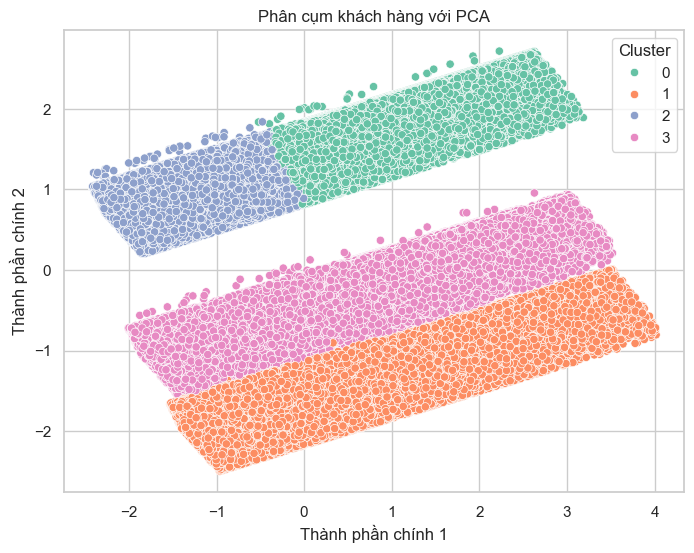

In [199]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cluster, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('Phân cụm khách hàng với PCA')
plt.xlabel('Thành phần chính 1')
plt.ylabel('Thành phần chính 2')
plt.show()

In [200]:
df_cluster.groupby('Cluster').mean()

,Total_Purchases,Total_Amount,Age,Ratings,Income_High,Income_Low,Income_Medium,PCA1,PCA2
Cluster,,,,,,,,,
0,8.041115,2305.206145,35.606616,3.133909,0.0,0.0,1.0,0.794021,1.691063
1,5.360974,1371.200308,38.303085,3.268678,0.0,1.0,0.0,0.529680,-1.430662
2,3.358848,666.134860,34.111651,3.139134,0.0,0.0,1.0,-1.278185,1.017312
3,5.347813,1360.775167,33.103922,3.060189,1.0,0.0,0.0,-0.002397,-0.430717


### Nhận xét:
1. Tổng quan từng cụm:
Dữ liệu cho thấy có **4 cụm khách hàng**:
- **Cụm 0 – Khách hàng thu nhập trung bình, mua nhiều và chi tiêu cao**
- **Cụm 1 – Khách hàng thu nhập trung bình, mua ít và chi tiêu thấp**
- **Cụm 2 – Khách hàng có thu nhập cao, chi tiêu ở mức trung bình**
- **Cụm 3 – Khách hàng có thu nhập thấp, chi tiêu trung bình**


2. Phân tích hành vi mua sắm theo từng cụm
- Cụm 0 có tổng chi tiêu cao nhất (2305.36) và số lần mua nhiều nhất (8.04). Đây có thể là nhóm khách hàng trung thành, có mức chi tiêu mạnh mẽ.
- Cụm 1 có tổng chi tiêu thấp nhất (666.34) và số lần mua ít nhất (3.36). Đây có thể là nhóm khách hàng ít mua sắm hoặc có ngân sách hạn chế.
- Cụm 2 và Cụm 3 có mức chi tiêu gần tương đương (≈1370) và số lần mua xấp xỉ nhau (≈5.36). Tuy nhiên:
  - Cụm 2 có thu nhập cao, nhưng chỉ chi tiêu ở mức trung bình.
  - Cụm 3 có thu nhập thấp, nhưng lại chi tiêu ngang bằng Cụm 2.

3. Ảnh hưởng của thu nhập đến hành vi mua sắm
Các cụm có sự khác biệt rõ rệt về mức thu nhập:
- Cụm 0 có thu nhập trung bình, nhưng vẫn chi tiêu 2305.36 → nhóm này có thể chi tiêu mạnh mẽ vì trung thành với thương hiệu.
- Cụm 1 có thu nhập trung bình, nhưng lại chi tiêu thấp → có thể là khách hàng chọn lọc sản phẩm hơn.
- Cụm 2 có thu nhập cao, nhưng lại chi tiêu ít hơn Cụm 0 → có thể là nhóm khách hàng cân nhắc mua sắm kỹ lưỡng.
- Cụm 3 có thu nhập thấp, nhưng mức chi tiêu tương đương Cụm 2 → có thể do họ ưu tiên mua hàng thiết yếu.

4. Đánh giá mức độ hài lòng của khách hàng
- Ratings trung bình của các cụm gần tương đương (~3.1), không có sự chênh lệch quá lớn về mức độ hài lòng.
- Cụm 3 có điểm đánh giá cao nhất (3.27), có thể do nhóm khách hàng này hài lòng với sản phẩm phù hợp với nhu cầu của họ.
- Cụm 2 có điểm đánh giá thấp nhất (3.06), có thể vì kỳ vọng cao hơn hoặc chưa tìm được sản phẩm ưng ý.


### Kết luận và đề xuất chiến lược
 - **Nhóm khách hàng trung thành (Cụm 0) nên được khai thác nhiều hơn**. 
 Họ có **số lần mua cao nhất** và **chi tiêu nhiều nhất**, nên cần tối ưu chương trình **khuyến mãi, ưu đãi VIP** để giữ chân.

 - **Cụm 1 cần được kích thích tiêu dùng**. 
 Mặc dù họ thuộc nhóm thu nhập trung bình, họ lại có mức chi tiêu thấp. Cần **chiến lược giá, quảng bá hoặc khuyến mãi** để tăng tần suất mua sắm.

 - **Cụm 2 có thu nhập cao nhưng chi tiêu trung bình**.
 Nhóm này có thể quan tâm đến **sản phẩm cao cấp**, **dịch vụ cá nhân hóa** để tối ưu hóa doanh thu.

 - **Cụm 3 có độ tuổi cao hơn**, nhưng vẫn chi tiêu gần bằng Cụm 1  
 Nhóm này có xu hướng **trung thành với thương hiệu**, nên cần tối ưu **chương trình khách hàng thân thiết**.

## Mô hình Phophet

### Chọn ra các đặc trưng

In [201]:
df_prophet = df[['Date', 'Total_Amount']].copy()

df_prophet = df_prophet.set_index('Date').resample('ME')['Total_Amount'].sum().reset_index()
df_prophet = df_prophet.rename(columns={'Date': 'ds', 'Total_Amount': 'y'})
df_prophet

,ds,y
0,2023-03-31,3.497032e+07
1,2023-04-30,3.379157e+07
2,2023-05-31,3.423922e+07
3,2023-06-30,3.349542e+07
4,2023-07-31,3.460431e+07
5,2023-08-31,3.499292e+07
6,2023-09-30,3.366410e+07
7,2023-10-31,3.427022e+07
8,2023-11-30,3.356149e+07
9,2023-12-31,3.445867e+07


### Xây dựng ProPhet

In [202]:
model = Prophet()
model.fit(df_prophet)

11:22:48 - cmdstanpy - INFO - Chain [1] start processing
11:22:49 - cmdstanpy - INFO - Chain [1] done processing


### Dự đoán doanh thu cho 6 tháng tiếp theo 

In [203]:
future = model.make_future_dataframe(periods=6, freq='ME')  

In [204]:
forecast = model.predict(future)
result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6)  
print(result)

           ds          yhat    yhat_lower    yhat_upper
12 2024-03-31  3.372327e+07  3.297471e+07  3.445233e+07
13 2024-04-30  3.366394e+07  3.291329e+07  3.440374e+07
14 2024-05-31  3.360263e+07  3.280126e+07  3.433448e+07
15 2024-06-30  3.354330e+07  3.284848e+07  3.434358e+07
16 2024-07-31  3.348200e+07  3.279071e+07  3.423566e+07
17 2024-08-31  3.342069e+07  3.264569e+07  3.416872e+07


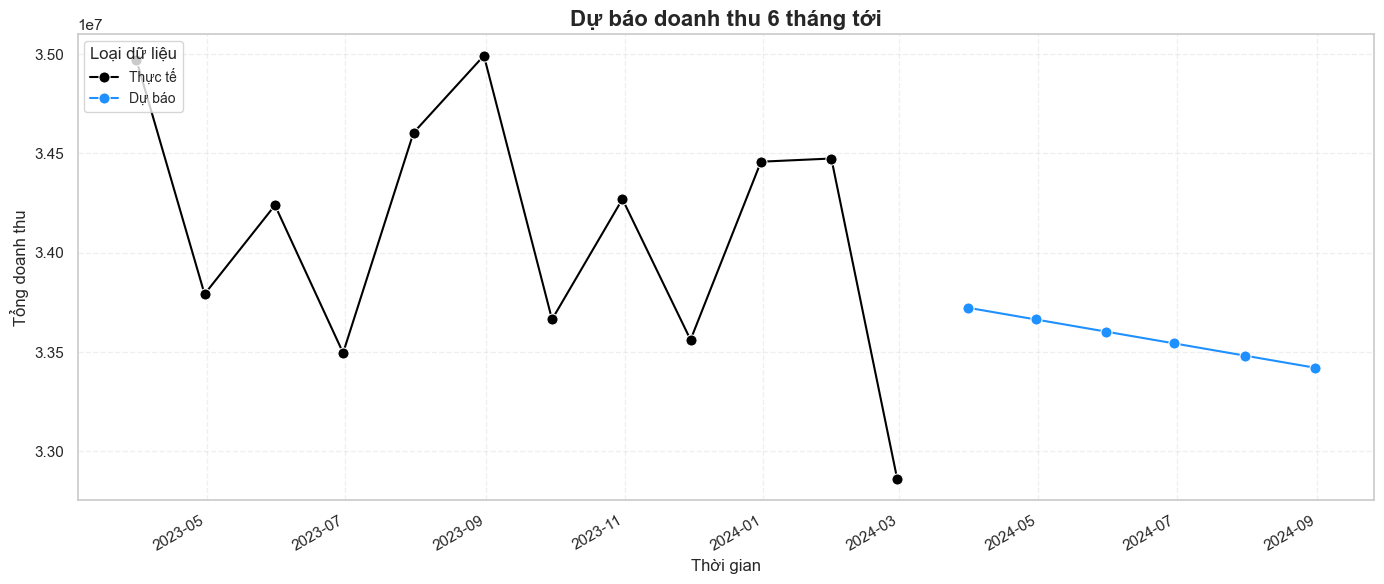

In [205]:
plot_data = forecast[['ds', 'yhat']].copy()
plot_data['type'] = ['Thực tế'] * len(df_prophet) + ['Dự báo'] * 6

real_data = df_prophet.rename(columns={'y': 'yhat'})
real_data['type'] = 'Thực tế'
plot_df = pd.concat([real_data[['ds', 'yhat', 'type']], plot_data.tail(6)])

plt.figure(figsize=(14,6))

palette = {'Thực tế': 'black', 'Dự báo': 'dodgerblue'}
sns.lineplot(data=plot_df, x='ds', y='yhat', hue='type', marker='o', markersize=8, palette=palette)

plt.title('Dự báo doanh thu 6 tháng tới', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Tổng doanh thu', fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Loại dữ liệu', loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### Nhận xét biểu đồ: 
1. Tổng quan xu hướng
- **Giai đoạn thực tế** (từ *03-2023 đến 02-2024*):  
  Doanh thu dao động nhưng nhìn chung giữ ở mức quanh ~**34.000.000**. Có những tháng tăng mạnh (như *08-2023*), sau đó giảm sâu (đặc biệt là *02-2024*).

- **Giai đoạn dự báo** (từ *03-2024 đến 09-2024*):  
  Mô hình dự báo cho thấy **xu hướng giảm nhẹ đều đặn theo thời gian**. Điều này phản ánh khả năng doanh thu đang bước vào giai đoạn suy giảm nếu không có sự can thiệp.

---

2. Biến động trong dữ liệu thực tế
- **Tháng 08-2023** là tháng có doanh thu cao nhất (đỉnh).
- **Tháng 02-2024** có doanh thu thấp nhất – có thể là dấu hiệu của **vấn đề kinh doanh**, **mùa thấp điểm** hoặc **yếu tố bất thường**.
---

3. Hàm ý kinh doanh
- Phân tích xu hướng doanh thu theo thời gian cho thấy mức sụt giảm rõ rệt vào tháng 02/2024. Nguyên nhân chủ yếu đến từ hiệu ứng mùa vụ: trong giai đoạn cuối năm (từ tháng 12 đến hết tháng 01), các thị trường lớn như Hoa Kỳ, Canada và Vương quốc Anh chứng kiến mức chi tiêu tiêu dùng tăng mạnh do các kỳ lễ lớn như Giáng Sinh, Boxing Day và Tết Dương lịch. Điều này dẫn đến việc doanh thu tăng trưởng mạnh trong thời gian đó. Tuy nhiên, ngay sau giai đoạn cao điểm mua sắm, người tiêu dùng có xu hướng giảm chi tiêu để cân đối tài chính, kéo theo sự sụt giảm doanh thu trong tháng 02. Sau thời điểm này, doanh thu bắt đầu hồi phục và dần ổn định trở lại trong các tháng tiếp theo.
---

4. Đánh giá dự báo
- Mô hình Prophet (hoặc tương đương) có xu hướng **ưu tiên mô hình hóa xu hướng tổng thể**, không phản ánh tốt các biến động ngắn hạn.
- Các giá trị dự báo thể hiện **xu hướng tuyến tính giảm**, không có tính dao động như dữ liệu thực tế.

**Ưu điểm:**
- Thể hiện rõ **xu hướng tổng thể** của doanh thu.

**Hạn chế:**
- **Chưa nắm bắt tốt tính mùa vụ** hoặc các **biến động đột ngột** đã xuất hiện trong dữ liệu lịch sử.
---

### Đánh giá mô hình 

In [206]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(model, initial='240 days', period='30 days', horizon='90 days')
df_p = performance_metrics(df_cv)

print(df_p)

  0%|          | 0/1 [00:00<?, ?it/s]

11:22:49 - cmdstanpy - INFO - Chain [1] start processing
11:22:49 - cmdstanpy - INFO - Chain [1] done processing


  horizon           mse           rmse            mae      mape     mdape  \
0 30 days  3.644671e+11  603711.109056  603711.109056  0.017520  0.017520   
1 61 days  4.701313e+11  685661.244387  685661.244387  0.019889  0.019889   
2 90 days  7.514403e+11  866856.546745  866856.546745  0.026380  0.026380   

      smape  coverage  
0  0.017675       1.0  
1  0.020089       0.0  
2  0.026036       0.0  


#### Nhận xét mô hình:

1. **RMSE**  
Là chỉ số đo sai số theo đơn vị thực tế (USD, Euro,...).  
- **Xu hướng:** RMSE tăng dần theo thời gian dự báo, từ 603k lên gần 869k.  
- **Diễn giải:** Dự báo càng xa thì sai số càng lớn, cho thấy mô hình hoạt động chính xác hơn ở ngắn hạn.

2. **MAPE**  
Là chỉ số đo sai số theo phần trăm (%), cho biết mô hình sai bao nhiêu phần trăm so với giá trị thực.  
- Giá trị MAPE khá thấp ở cả 3 mốc thời gian (đều < 3%) → mô hình có độ chính xác tốt.  
- Tuy nhiên, MAPE cũng tăng dần, phản ánh rằng sai số tăng nhẹ theo thời gian.

3. **Kết luận**  
- Mô hình hoạt động tốt và ổn định trong ngắn hạn (30–60 ngày).  
- Cần theo dõi kỹ khi áp dụng cho dự báo dài hạn (trên 90 ngày).  

### Kết luận và Đề xuất

**Kết luận:**  
Dữ liệu cho thấy **doanh thu có tính chu kỳ rõ rệt**, với **đỉnh cao vào dịp lễ cuối năm** và **sụt giảm mạnh ngay sau đó**, đặc biệt là *tháng 02/2024*.  
Xu hướng dự báo cho thấy doanh thu có thể tiếp tục **giảm nhẹ** nếu không có biện pháp can thiệp. Điều này phản ánh ảnh hưởng của **yếu tố mùa vụ** và **hành vi tiêu dùng sau kỳ nghỉ**.

---

**Đề xuất:**

- **Chủ động xây dựng kế hoạch kích cầu sau kỳ nghỉ lễ**  
  (ví dụ: khuyến mãi đầu năm, chiến dịch hoàn tiền, combo tiết kiệm...).

- **Đa dạng hóa kênh bán hàng** và mở rộng sang các thị trường **ít chịu ảnh hưởng bởi mùa vụ**.

- **Phân tích chuyên sâu các yếu tố ảnh hưởng đến tháng 02**  để xác định có hay không các nguyên nhân nội tại như:  
  *thay đổi chính sách giá, biến động thị trường...*

- **Theo dõi sát dữ liệu theo ngày hoặc tuần** nhằm phát hiện **sớm các biến động bất thường** và đưa ra phản ứng kịp thời.

---
